<a href="https://colab.research.google.com/github/danielli-arcari/ProjetodeAnalise_BasedeDadosIMDB/blob/main/Projeto_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Filmes: reputação x retorno financeiro
Treinamento de Exploração e Análise de Dados | Base: IMDB Movies (Kaggle)

O cliente: produz e distribui filmes e quer decidir onde investir.

A pergunta central: o que faz um filme ser bem aceito pelo público, o que faz um filme dar retorno financeiro e onde essas duas coisas não andam juntas.

Como ler este notebook: o código está oculto para a apresentação. Clique em "Mostrar código" em qualquer célula para ver a implementação. As 9 perguntas de negócio estão na seção 5.

## Limpeza e padronização: IMDB Movies
**Objetivo**: deixar a base pronta para análise, documentando cada problema encontrado e a decisão tomada.

**Roteiro:**

1-Setup e carga dos dados

2-Diagnóstico de qualidade (o que está errado antes de limpar)

3-Limpeza e padronização

4-Exportação da base limpa e dicionário de colunas

###1. Setup e carga dos dados

In [57]:
import os, re, time, unicodedata
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from google.colab import drive

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

drive.mount("/content/drive")
PASTA = "/content/drive/MyDrive/TreinamentoNycollasRegilene"
CAMINHO = f"{PASTA}/imdb_movies.csv"
PASTA_FIGURAS = f"{PASTA}/figuras"
os.makedirs(PASTA_FIGURAS, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
# Carregamento do arquivo original
df_raw = pd.read_csv(CAMINHO)
print(f"Linhas: {df_raw.shape[0]:,} | Colunas: {df_raw.shape[1]}")

Linhas: 10,178 | Colunas: 12


In [59]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


In [60]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
score,"10,178.00",63.50,13.54,0.00,59.00,65.00,71.00,100.00
budget_x,"10,178.00","64,882,378.89","57,075,645.28",1.00,"15,000,000.00","50,000,000.00","105,000,000.00","460,000,000.00"
revenue,"10,178.00","253,140,093.42","277,788,048.78",0.00,"28,588,985.00","152,934,876.50","417,802,077.10","2,923,706,026.00"


In [61]:
df_raw.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.00,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,"75,000,000.00","271,616,668.00",AU
1,Avatar: The Way of Water,12/15/2022,78.00,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,"460,000,000.00","2,316,794,914.00",AU
2,The Super Mario Bros. Movie,04/05/2023,76.00,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,"100,000,000.00","724,459,031.00",AU
3,Mummies,01/05/2023,70.00,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian","12,300,000.00","34,200,000.00",AU
4,Supercell,03/17/2023,61.00,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,"77,000,000.00","340,941,958.60",US


In [62]:
# Salva automaticamente cada gráfico exibido daqui em diante
if not hasattr(plt, "_show_original"):
    plt._show_original = plt.show
_numero_figura = {"n": 0}

def _nome_arquivo(fig):
    titulo = next((ax.get_title() for ax in fig.axes if ax.get_title()), "figura")
    titulo = unicodedata.normalize("NFKD", titulo).encode("ascii", "ignore").decode().lower()
    return re.sub(r"[^a-z0-9]+", "_", titulo).strip("_")[:50]

def mostrar_e_salvar(*args, **kwargs):
    fig = plt.gcf()
    _numero_figura["n"] += 1
    caminho = f"{PASTA_FIGURAS}/{_numero_figura['n']:02d}_{_nome_arquivo(fig)}.png"
    fig.savefig(caminho, dpi=200, bbox_inches="tight")
    print(f"Figura salva: {caminho}")
    plt._show_original(*args, **kwargs)

plt.show = mostrar_e_salvar

### 2. Diagnóstico de qualidade



In [63]:
# 2.1 Nulos
print("Nulos por coluna:")
print(df_raw.isna().sum()[lambda s: s > 0], "\n")

# 2.2 Status e notas zeradas (filmes não lançados não têm nota real)
print("Status:")
print(df_raw["status"].value_counts(), "\n")
print(f"Filmes com nota 0: {(df_raw['score'] == 0).sum()}")
print(df_raw.loc[df_raw["score"] == 0, "status"].value_counts(), "\n")

# 2.3 Espaços e caracteres invisíveis
print("Exemplo de gênero cru:", repr(df_raw["genre"].iloc[0]))
print("Exemplo de idioma cru:", repr(df_raw["orig_lang"].iloc[0]))
print("Exemplo de data crua:", repr(df_raw["date_x"].iloc[0]), "\n")

# 2.4 Sinopse placeholder
placeholder = df_raw["overview"].str.contains("We don't have an overview", na=False)
print(f"Sinopses placeholder (sem sinopse real): {placeholder.sum()}")

Nulos por coluna:
genre    85
crew     56
dtype: int64 

Status:
status
Released           10131
Post Production       31
In Production         16
Name: count, dtype: int64 

Filmes com nota 0: 211
status
Released           164
Post Production     31
In Production       16
Name: count, dtype: int64 

Exemplo de gênero cru: 'Drama,\xa0Action'
Exemplo de idioma cru: ' English'
Exemplo de data crua: '03/02/2023 ' 

Sinopses placeholder (sem sinopse real): 89


In [64]:
# 2.5 Sinais de dados financeiros imputados/fabricados
# Bilheteria real vem em dólares inteiros. Valores com centavos (ex.: 175.269.998,80)
# e valores idênticos repetidos em muitos filmes diferentes indicam preenchimento artificial.
rev_centavos = (df_raw["revenue"] % 1 != 0)
bud_centavos = (df_raw["budget_x"] % 1 != 0)
rev_repetida = df_raw["revenue"].map(df_raw["revenue"].value_counts()) >= 2
bud_quebrado = (df_raw["budget_x"] % 1_000_000 != 0)

print(f"Receitas com centavos: {rev_centavos.sum():,} ({rev_centavos.mean():.1%})")
print(f"Orçamentos com centavos: {bud_centavos.sum():,}")
print(f"Receitas repetidas em 2+ filmes: {rev_repetida.sum():,}")
print(f"Orçamentos não redondos (não múltiplos de US$ 1 mi): {bud_quebrado.sum():,}")
print(f"Receita = 0: {(df_raw['revenue'] == 0).sum()}\n")

print("Receitas mais repetidas (mesmo valor para filmes distintos):")
print(df_raw["revenue"].value_counts().head(5), "\n")

print("Exemplo: filmes com nota 100 (suspeitos, com orçamento e receita idênticos):")
print(df_raw.loc[df_raw["score"] == 100, ["names", "budget_x", "revenue"]].head())


Receitas com centavos: 3,398 (33.4%)
Orçamentos com centavos: 328
Receitas repetidas em 2+ filmes: 2,762
Orçamentos não redondos (não múltiplos de US$ 1 mi): 4,679
Receita = 0: 73

Receitas mais repetidas (mesmo valor para filmes distintos):
revenue
175,269,998.80    143
0.00               73
38,139,010.00      55
178,359,863.00     43
1,240,261.60       29
Name: count, dtype: int64 

Exemplo: filmes com nota 100 (suspeitos, com orçamento e receita idênticos):
                                  names       budget_x          revenue
277                    Orgasm Lecture 2 201,000,000.00 1,569,323,843.80
443                        El asistente 201,000,000.00 1,569,323,843.80
934                  Female Boss Hooker 201,000,000.00 1,569,323,843.80
1776  Porno document: Toruko tokkyû bin 201,000,000.00 1,569,323,843.80
4887              Pretty Young Sister 4 201,000,000.00 1,569,323,843.80


In [65]:
# 2.6 Homônimos que "herdaram" a bilheteria de outro filme
# Ex.: Titanic (1953) aparece com a mesma receita do Titanic (1997).
exemplos = ["Titanic", "The Lion King", "Frozen", "The Avengers", "A Nightmare on Elm Street"]
print(df_raw.loc[df_raw["names"].isin(exemplos), ["names", "date_x", "score", "budget_x", "revenue"]]
      .sort_values(["names", "date_x"]).to_string())

dup_titulo_data = df_raw.duplicated(["names", "date_x"]).sum()
print(f"\nLinhas duplicadas por título + data: {dup_titulo_data}")

                          names       date_x  score       budget_x          revenue
2810  A Nightmare on Elm Street  05/20/2010   55.00  35,000,000.00   117,729,618.00
2811  A Nightmare on Elm Street  05/20/2010   55.00   1,800,000.00    25,542,906.00
2373  A Nightmare on Elm Street  08/01/1985   73.00  35,000,000.00   117,729,618.00
2374  A Nightmare on Elm Street  08/01/1985   73.00   1,800,000.00    25,542,906.00
6040                     Frozen  02/05/2010   60.00 150,000,000.00 1,256,887,580.00
486                      Frozen  12/26/2013   72.00 150,000,000.00 1,256,887,580.00
211                The Avengers  04/25/2012   77.00 225,000,000.00 1,515,100,211.00
212                The Avengers  04/25/2012   77.00  60,000,000.00    48,585,416.00
3496               The Avengers  11/05/1998   44.00 225,000,000.00 1,515,100,211.00
3497               The Avengers  11/05/1998   44.00  60,000,000.00    48,585,416.00
471               The Lion King  07/17/2019   71.00 260,000,000.00 1,647,733

In [66]:
# 2.7 O que tem de fato na coluna "crew"?
# Padrão: "Ator, Personagem, Ator, Personagem..." Ou seja, só elenco.
# Não há diretor, roteirista nem produtor.
partes = [p.strip() for p in df_raw["crew"].iloc[0].split(",")]
exemplo_crew = pd.DataFrame(list(zip(partes[0::2], partes[1::2])),
                            columns=["Posição par: ator", "Posição ímpar: personagem"])

print(f"Filme: {df_raw['names'].iloc[0]}")
exemplo_crew.head(6)

Filme: Creed III


,Posição par: ator,Posição ímpar: personagem
0,Michael B. Jordan,Adonis Creed
1,Tessa Thompson,Bianca Taylor
2,Jonathan Majors,Damien Anderson
3,Wood Harris,Tony 'Little Duke' Evers
4,Phylicia Rashād,Mary Anne Creed
5,Mila Davis-Kent,Amara Creed


#### Resultados obtidos

**2.2 Status e nota 0:** 164 dos 211 filmes com nota 0 estão marcados como "Released". O status sozinho não basta para filtrar, por isso a limpeza usa as duas condições.

**2.5 Dados financeiros fabricados:** 3.398 receitas (33,4%) têm centavos, o que não existe em bilheteria real, e o valor US\$ 175.269.998,80 se repete em 143 filmes diferentes. Os cinco filmes com nota 100 têm exatamente o mesmo orçamento e a mesma receita: é a prova mais visual de dado preenchido artificialmente.

**2.6 Homônimos:** The Lion King (2019) aparece duas vezes, uma com a própria bilheteria (US\$ 1,65 bi) e outra com a do filme de 1994 (US\$ 986 mi). Titanic (1953) aparece com a receita do Titanic (1997). A base cruzou os dados de lançamentos diferentes com o mesmo título.

**2.7 Coluna crew:** a coluna se chama "equipe", mas só traz atores e personagens. Não há diretor, roteirista nem produtor. Essa é a resposta direta à pergunta 4 do cliente.

### 3. Limpeza e padronização dos dados

**3.1 Padronização:** nomes de colunas em português (a coluna `crew` passa a se chamar `elenco`), textos sem espaços extras e datas convertidas.

In [67]:
df = df_raw.copy()

df = df.rename(columns={
    "names": "titulo", "date_x": "data_lancamento", "score": "nota", "genre": "genero",
    "overview": "sinopse", "crew": "elenco", "orig_title": "titulo_original",
    "status": "status", "orig_lang": "idioma", "budget_x": "orcamento",
    "revenue": "receita", "country": "pais",
})

# Textos: remove o caractere invisível \xa0, espaços nas pontas e espaços duplos
colunas_texto = ["titulo", "data_lancamento", "genero", "sinopse", "elenco",
                 "titulo_original", "status", "idioma", "pais"]
for c in colunas_texto:
    df[c] = (df[c].astype("string")
                  .str.replace("\xa0", " ", regex=False)
                  .str.replace(r"\s+", " ", regex=True)
                  .str.strip())

# Datas e derivados
df["data_lancamento"] = pd.to_datetime(df["data_lancamento"], format="%m/%d/%Y", errors="coerce")
df["ano"] = df["data_lancamento"].dt.year
df["decada"] = (df["ano"] // 10 * 10).astype("Int64")
df["mes"] = df["data_lancamento"].dt.month

print(f"Datas inválidas após conversão: {df['data_lancamento'].isna().sum()}")
print(f"Período coberto: {df['ano'].min()} a {df['ano'].max()}")
print("Colunas:", list(df.columns))

Datas inválidas após conversão: 0
Período coberto: 1903 a 2023
Colunas: ['titulo', 'data_lancamento', 'nota', 'genero', 'sinopse', 'elenco', 'titulo_original', 'status', 'idioma', 'orcamento', 'receita', 'pais', 'ano', 'decada', 'mes']


**3.2 Filtro:** saem os filmes não lançados e os que têm nota 0 (sem avaliação real do público).

In [68]:
n0 = len(df)
df = df[(df["status"] == "Released") & (df["nota"] > 0)].copy()
print(f"Removidos (não lançados ou nota 0): {n0 - len(df)}")
print(f"Filmes restantes: {len(df):,}")

Removidos (não lançados ou nota 0): 211
Filmes restantes: 9,967


**3.3 Linhas duplicadas: verificar antes de remover.**

Linha duplicada é o *mesmo filme* registrado mais de uma vez: mesmo título, mesma data, mesma sinopse, mesmo elenco e mesma nota. Um remake nunca cai nessa regra, porque tem data, elenco e sinopse diferentes do original. A célula abaixo prova isso com os dados antes de remover qualquer linha.

In [69]:
chave = ["titulo", "data_lancamento"]
mesmo_titulo_data = df[df.duplicated(chave, keep=False)]
conferencia = mesmo_titulo_data.groupby(chave).agg(
    linhas=("nota", "size"),
    sinopses=("sinopse", lambda s: s.nunique(dropna=False)),
    elencos=("elenco", lambda s: s.nunique(dropna=False)),
    notas=("nota", "nunique"),
    receitas=("receita", "nunique"),
)
conteudo_igual = (conferencia[["sinopses", "elencos", "notas"]] == 1).all(axis=1)
print(f"Grupos com mesmo título e mesma data: {len(conferencia)}")
print(f"  com sinopse, elenco e nota idênticos (mesmo filme): {conteudo_igual.sum()}")
print(f"  com conteúdo diferente (filmes distintos): {(~conteudo_igual).sum()}")
print(f"  em que as linhas diferem na receita (dado cruzado): {(conferencia['receitas'] > 1).sum()}")

# Conflito financeiro: o mesmo filme aparece com receitas diferentes nas linhas duplicadas
df["conflito_financeiro"] = df.groupby(chave)["receita"].transform("nunique") > 1

# Remoção: só o que é comprovadamente o mesmo filme
n0 = len(df)
df = df.drop_duplicates(subset=chave + ["sinopse", "elenco", "nota"], keep="first")
print(f"\nLinhas duplicadas removidas: {n0 - len(df)}")

# Homônimos com a mesma receita: a bilheteria pertence ao lançamento mais recente
# (ex.: Titanic 1953 aparece com a receita do Titanic 1997). Os mais antigos ficam marcados.
df = df.sort_values("data_lancamento", ascending=False)
df["homonimo_herdado"] = df.duplicated(subset=["titulo", "receita"], keep="first")
df = df.sort_index()
print(f"Filmes com conflito financeiro: {df['conflito_financeiro'].sum()}")
print(f"Filmes que herdaram bilheteria de homônimo: {df['homonimo_herdado'].sum()}")

Grupos com mesmo título e mesma data: 166
  com sinopse, elenco e nota idênticos (mesmo filme): 166
  com conteúdo diferente (filmes distintos): 0
  em que as linhas diferem na receita (dado cruzado): 166

Linhas duplicadas removidas: 177
Filmes com conflito financeiro: 166
Filmes que herdaram bilheteria de homônimo: 212


3.4 Revisão dos IDs. A base original não tem coluna de identificação: o único "ID" era o índice do pandas, que ficou com buracos depois das remoções (ia de 0 a 10.177, mas agora faltam 388 números). Isso atrapalha qualquer cruzamento com fontes externas. Criamos:

id: identificador interno sequencial, um por filme, sem buracos;
wikidata_id: identificador universal do filme no Wikidata (preenchido na 3.6). É ele que resolve de vez o problema dos homônimos, porque Titanic (1953) e Titanic (1997) têm IDs diferentes.

In [70]:
df = df.reset_index(drop=True)
df.insert(0, "id", range(1, len(df) + 1))

assert df["id"].is_unique, "Há IDs repetidos"
assert (df["id"].diff().dropna() == 1).all(), "Há buracos na sequência de IDs"
print(f"IDs de {df['id'].min()} a {df['id'].max()} para {len(df):,} filmes: únicos e sem buracos.")

IDs de 1 a 9790 para 9,790 filmes: únicos e sem buracos.


In [71]:
# Chave auxiliar para comparar títulos (sem acentos, pontuação e maiúsculas: "Ben Hur" = "Ben-Hur")

def normalizar_titulo(t):
    t = unicodedata.normalize("NFKD", str(t)).encode("ascii", "ignore").decode().lower()
    return re.sub(r"[^a-z0-9]+", " ", t).strip()

df["titulo_normalizado"] = df["titulo"].map(normalizar_titulo)

# A Wikimedia pede que todo acesso automatizado se identifique. Troque pelo seu e-mail.
HEADERS = {"User-Agent": "TreinamentoAnaliseDados/1.0 (axiadmc@gmail.com)"}

**3.5 Remakes (Wikipedia, ao vivo).**

A célula baixa as páginas [List of film remakes (A-M)](https://en.wikipedia.org/wiki/List_of_film_remakes_(A%E2%80%93M)) e [(N-Z)](https://en.wikipedia.org/wiki/List_of_film_remakes_(N%E2%80%93Z)), lê as tabelas "Original | Remake(s)" e cria a coluna `E_remake?`: **1** quando o filme aparece na lista como remake, **0** quando não aparece.

Pela definição da Wikipedia, não entram novas adaptações da mesma fonte (*Dune*, 2021), reboots (*Ghostbusters*, 2016) nem sequências com o mesmo título (*Halloween*, 2018). A base usa a data de estreia em cada país (em geral Austrália), então o ano pode diferir em até 2 anos do ano da Wikipedia; essa tolerância é aplicada na comparação.

In [72]:
URLS_REMAKES = [
    "https://en.wikipedia.org/wiki/List_of_film_remakes_(A%E2%80%93M)",
    "https://en.wikipedia.org/wiki/List_of_film_remakes_(N%E2%80%93Z)",
]
PADRAO_FILME = re.compile(r"([^()]+?)\s*\((\d{4})[^)]*\)")

def extrair_filmes(texto):
    """Extrai pares (título, ano) de textos como 'Cape Fear (1962)' ou 'X (1990)Y (2004)'."""
    if pd.isna(texto):
        return []
    texto = re.sub(r"\((?!\d{4})[^)]*\)", " ", str(texto))   # remove parênteses sem ano, ex.: "(Turkish remake)"
    filmes = []
    for titulo, ano in PADRAO_FILME.findall(texto):
        titulo = titulo.strip(" ,;.-\u2013")
        if titulo:
            filmes.append((titulo, int(ano)))
    return filmes

def baixar_remakes_wikipedia(urls):
    registros = []
    for url in urls:
        resposta = requests.get(url, headers=HEADERS, timeout=30)
        resposta.raise_for_status()
        for tabela in pd.read_html(StringIO(resposta.text)):
            col_original = next((c for c in tabela.columns if "original" in str(c).lower()), None)
            col_remake = next((c for c in tabela.columns if "remake" in str(c).lower()), None)
            if col_original is None or col_remake is None:
                continue
            for _, linha in tabela.iterrows():
                originais = extrair_filmes(linha[col_original])
                original_txt = "; ".join(f"{t} ({a})" for t, a in originais)
                for titulo, ano in extrair_filmes(linha[col_remake]):
                    registros.append({"titulo_wiki": titulo, "ano_wiki": ano, "original_wiki": original_txt})
        time.sleep(1)
    return pd.DataFrame(registros).drop_duplicates()

try:
    remakes_wiki = baixar_remakes_wikipedia(URLS_REMAKES)
except Exception as erro:
    raise RuntimeError(f"Não foi possível acessar a Wikipedia ({erro}). Verifique a conexão do Colab e rode a célula de novo.")
remakes_wiki["titulo_normalizado"] = remakes_wiki["titulo_wiki"].map(normalizar_titulo)
print(f"Remakes lidos da Wikipedia: {len(remakes_wiki):,}")

# Cruzamento: mesmo título normalizado e ano com diferença de até 2 anos
TOLERANCIA_ANOS = 2
pares = df[["id", "titulo_normalizado", "ano"]].merge(remakes_wiki, on="titulo_normalizado")
pares = pares[(pares["ano"] - pares["ano_wiki"]).abs() <= TOLERANCIA_ANOS]
pares = pares.sort_values(["id", "ano_wiki"]).drop_duplicates("id")   # um registro por filme

df["E_remake?"] = df["id"].isin(pares["id"]).astype(int)
df = df.drop(columns=["original_wiki"], errors="ignore")   # permite rodar a célula de novo
df = df.merge(pares[["id", "original_wiki"]], on="id", how="left")

print(f"Filmes marcados como remake (E_remake? = 1): {df['E_remake?'].sum()}")
print("\nAmostra para conferência:")
print(df.loc[df["E_remake?"] == 1, ["id", "titulo", "ano", "original_wiki"]]
      .sort_values("ano", ascending=False).head(10).to_string(index=False))

# Títulos que casaram com mais de um filme da base: conferir manualmente
ambiguos = df[df["E_remake?"] == 1].groupby(["titulo_normalizado", "ano"]).filter(lambda g: len(g) > 1)
if len(ambiguos):
    print("\nAtenção: mesmo título e ano para mais de um filme (só um deles deve ser o remake):")
    print(ambiguos[["id", "titulo", "data_lancamento", "sinopse"]]
          .assign(sinopse=lambda d: d["sinopse"].str[:60] + "...").to_string(index=False))

# Correção manual: há dois "Cats" de 2019 na base; só o musical (sinopse com "Jellicles") é o remake de Cats (1998)
outro_cats = (df["titulo"] == "Cats") & (df["ano"] == 2019) & ~df["sinopse"].str.contains("Jellicle", case=False, na=False)
corrigidos = (outro_cats & (df["E_remake?"] == 1)).sum()
df.loc[outro_cats, "E_remake?"] = 0
df.loc[outro_cats, "original_wiki"] = pd.NA
print(f"Correção manual aplicada: {corrigidos} filme(s) 'Cats' que não é o musical voltou para E_remake? = 0")

Remakes lidos da Wikipedia: 766
Filmes marcados como remake (E_remake? = 1): 214

Amostra para conferência:
  id                                   titulo  ano                              original_wiki
  54                        A Man Called Otto 2023                    A Man Called Ove (2015)
 121                Prancer: A Christmas Tale 2022                             Prancer (1989)
 382                                Pinocchio 2022                           Pinocchio (1940)
 548         Paws of Fury: The Legend of Hank 2022                     Blazing Saddles (1974)
 272 Doraemon: Nobita's Little Star Wars 2021 2022 Doraemon: Nobita's Little Star Wars (1985)
 983                       My Father's Dragon 2022                  My Father's Dragon (1997)
2891                     Cheaper by the Dozen 2022                Cheaper by the Dozen (1950)
3535                      Father of the Bride 2022                 Father of the Bride (1950)
3552                                     Cube 

**3.6 Diretor (Wikidata, ao vivo).**

O diretor de cada filme vem do **Wikidata**, a base de dados estruturada da Wikimedia que alimenta as caixas de informação da Wikipedia (o campo "Directed by"). Abrir 9.790 páginas da Wikipedia uma a uma levaria horas e esbarraria em limites de acesso; o Wikidata responde em lotes de 100 títulos por consulta, em poucos minutos.

Regras do cruzamento: o título em inglês precisa ser igual ao rótulo do Wikidata, o item precisa ser um filme, e o ano de lançamento pode diferir em até 2 anos. Quando há mais de um candidato (homônimos), fica o de ano mais próximo. Filmes com mais de um diretor recebem os nomes separados por vírgula.

O resultado é salvo em `diretores_wikidata.csv` no Drive. Se a célula for executada de novo, ela reaproveita o arquivo em vez de consultar tudo outra vez.

In [73]:
URL_WIKIDATA = "https://query.wikidata.org/sparql"
ARQUIVO_CACHE = f"{PASTA}/diretores_wikidata.csv"
FORCAR_NOVA_CONSULTA = False   # True = ignora o arquivo salvo e consulta o Wikidata de novo
TAMANHO_LOTE = 100

def escapar(texto):
    return str(texto).replace("\\", "\\\\").replace('"', '\"')

def consultar_lote(titulos):
    # Cada título é procurado com rótulo em inglês (@en) e com o rótulo universal (@mul),
    # que o Wikidata passou a usar para nomes iguais em todos os idiomas.
    valores = " ".join(f'"{escapar(t)}"@en "{escapar(t)}"@mul' for t in titulos)
    consulta = f"""
    SELECT ?filme ?titulo ?data ?diretorLabel WHERE {{
      hint:Query hint:optimizer "None" .
      VALUES ?titulo {{ {valores} }}
      ?filme rdfs:label ?titulo .
      ?filme wdt:P31/wdt:P279* wd:Q11424 .
      ?filme wdt:P57 ?diretor .
      OPTIONAL {{ ?filme wdt:P577 ?data . }}
      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "en,mul,pt,es,fr,de,it,ja,ko,zh". }}
    }}"""
    for tentativa in range(3):
        try:
            resposta = requests.post(URL_WIKIDATA, data={"query": consulta, "format": "json"},
                                     headers=HEADERS, timeout=120)
            resposta.raise_for_status()
            return resposta.json()["results"]["bindings"]
        except Exception as erro:
            if tentativa == 2:
                print(f"  lote falhou após 3 tentativas: {erro}")
                return []
            time.sleep(5 * (tentativa + 1))

def buscar_diretores(titulos):
    linhas = []
    lotes = [titulos[i:i + TAMANHO_LOTE] for i in range(0, len(titulos), TAMANHO_LOTE)]
    for n, lote in enumerate(lotes, start=1):
        for r in consultar_lote(lote):
            linhas.append({
                "wikidata_id": r["filme"]["value"].rsplit("/", 1)[-1],
                "titulo": r["titulo"]["value"],
                "ano_wd": int(r["data"]["value"][:4]) if "data" in r and r["data"]["value"][:4].isdigit() else None,
                "diretor": r["diretorLabel"]["value"],
            })
        if n % 10 == 0 or n == len(lotes):
            print(f"  lote {n} de {len(lotes)}")
        time.sleep(1)
    return pd.DataFrame(linhas, columns=["wikidata_id", "titulo", "ano_wd", "diretor"])

if os.path.exists(ARQUIVO_CACHE) and not FORCAR_NOVA_CONSULTA:
    wd = pd.read_csv(ARQUIVO_CACHE)
    print(f"Usando resultados salvos em {ARQUIVO_CACHE}")
else:
    titulos_unicos = df["titulo"].dropna().unique().tolist()
    print(f"Consultando {len(titulos_unicos):,} títulos no Wikidata...")
    wd = buscar_diretores(titulos_unicos)
    wd.to_csv(ARQUIVO_CACHE, index=False)

# Um item do Wikidata pode ter várias datas (uma por país): fica o ano mais antigo.
# Vários diretores: nomes unidos por vírgula.
filmes_wd = (wd.groupby(["wikidata_id", "titulo"])
               .agg(ano_wd=("ano_wd", "min"),
                    Diretor=("diretor", lambda s: ", ".join(sorted(set(s.dropna())))))
               .reset_index())

# Cruzamento com a base: mesmo título, ano com diferença de até 2 anos, candidato de ano mais próximo
cand = df[["id", "titulo", "ano"]].merge(filmes_wd, on="titulo")
cand["dif_ano"] = (cand["ano"] - cand["ano_wd"]).abs()
cand = cand[cand["dif_ano"] <= TOLERANCIA_ANOS].sort_values(["id", "dif_ano"]).drop_duplicates("id")

# Um item do Wikidata só pode corresponder a um filme da base: fica o de ano mais próximo
melhor = cand.groupby("wikidata_id")["dif_ano"].transform("min")
cand = cand[cand["dif_ano"] == melhor]
empatados = cand[cand.duplicated("wikidata_id", keep=False)]
if len(empatados):
    print("Mesmo item do Wikidata para mais de um filme (diretor removido; conferir manualmente):")
    print(empatados[["id", "titulo", "ano", "wikidata_id", "Diretor"]].sort_values("wikidata_id").to_string(index=False))
cand = cand[~cand["wikidata_id"].isin(empatados["wikidata_id"])]
assert cand["wikidata_id"].is_unique, "Ainda há wikidata_id repetido"

df = df.drop(columns=["wikidata_id", "Diretor"], errors="ignore")   # permite rodar a célula de novo
df = df.merge(cand[["id", "wikidata_id", "Diretor"]], on="id", how="left")
print(f"\nFilmes com diretor encontrado: {df['Diretor'].notna().sum():,} de {len(df):,} ({df['Diretor'].notna().mean():.0%})")
df[["id", "titulo", "ano", "wikidata_id", "Diretor"]].head(10)


Usando resultados salvos em /content/drive/MyDrive/TreinamentoNycollasRegilene/diretores_wikidata.csv
Mesmo item do Wikidata para mais de um filme (diretor removido; conferir manualmente):
  id                             titulo  ano wikidata_id         Diretor
 450                       The Princess 2022  Q111942703     Le-Van Kiet
2869                       The Princess 2022  Q111942703     Le-Van Kiet
 903                               Mira 2022  Q114860297 Dmitry Kiselyov
 940                               Mira 2022  Q114860297 Dmitry Kiselyov
2144                              Alone 2021  Q121000208        Paul Tom
6876                              Alone 2021  Q121000208        Paul Tom
1267 Journey to the Center of the Earth 2008   Q15622394     T. J. Scott
6901 Journey to the Center of the Earth 2008   Q15622394     T. J. Scott
4297                        Escape Room 2017   Q29963486     Peter Dukes
5182                        Escape Room 2017   Q29963486     Peter Dukes
7642    

,id,titulo,ano,wikidata_id,Diretor
0,1,Creed III,2023,Q110664384,Michael B. Jordan
1,2,Avatar: The Way of Water,2022,Q3604746,James Cameron
2,3,The Super Mario Bros. Movie,2023,Q108671102,"Aaron Horvath, Michael Jelenic"
3,4,Mummies,2023,Q116005474,Juan Jesús García Galocha
4,5,Supercell,2023,Q108101613,Herbert James Winterstern
5,6,Cocaine Bear,2023,Q105840301,Elizabeth Banks
6,7,John Wick: Chapter 4,2023,Q80322358,Chad Stahelski
7,8,Puss in Boots: The Last Wish,2022,Q31271384,Joel Crawford
8,9,Attack on Titan,2022,NaN,NaN
9,10,The Park,2023,NaN,NaN


**3.7 Estrutura:** gêneros e atores viram listas, sinopses vazias viram nulo e rótulos de idioma são unificados.

In [74]:
df["genero"] = df["genero"].fillna("Não informado")
df["generos_lista"] = df["genero"].str.split(r"\s*,\s*")
df["genero_principal"] = df["generos_lista"].str[0]
df["qtd_generos"] = df["generos_lista"].str.len()

# Elenco: a coluna vem como "Ator, Personagem, Ator, Personagem..."; a lista 'atores' guarda só os atores
def extrair_atores(texto):
    if pd.isna(texto) or texto == "":
        return []
    partes = [p.strip() for p in str(texto).split(",")]
    return [p for p in partes[0::2] if p]

df["atores"] = df["elenco"].apply(extrair_atores)
df["qtd_elenco"] = df["atores"].str.len()

df.loc[df["sinopse"].str.contains("We don't have an overview", na=False), "sinopse"] = pd.NA

df["idioma"] = df["idioma"].replace({"Spanish, Castilian": "Spanish",
                                     "Dutch, Flemish": "Dutch",
                                     "Catalan, Valencian": "Catalan"})
df[["idioma", "pais", "genero_principal"]] = df[["idioma", "pais", "genero_principal"]].astype("category")

print(f"Sinopses sem conteúdo real: {df['sinopse'].isna().sum()}")
df[["id", "titulo", "genero_principal", "qtd_generos", "atores", "qtd_elenco"]].head()

Sinopses sem conteúdo real: 54


,id,titulo,genero_principal,qtd_generos,atores,qtd_elenco
0,1,Creed III,Drama,2,"[Michael B. Jordan, Tessa Thompson, Jonathan M...",9
1,2,Avatar: The Way of Water,Science Fiction,3,"[Sam Worthington, Zoe Saldaña, Sigourney Weave...",9
2,3,The Super Mario Bros. Movie,Animation,5,"[Chris Pratt, Anya Taylor-Joy, Charlie Day, Ja...",9
3,4,Mummies,Animation,5,"[Óscar Barberán, Ana Esther Alborg, Luis Pérez...",9
4,5,Supercell,Action,1,"[Skeet Ulrich, Anne Heche, Daniel Diemer, Jord...",9


**3.8 Confiabilidade financeira:** só entram nas análises de dinheiro os filmes cuja receita e orçamento passam em todos os testes de consistência.

In [75]:
contagem_receita = df["receita"].map(df.loc[~df["homonimo_herdado"], "receita"].value_counts())

df["financeiro_confiavel"] = (
    (df["receita"] % 1 == 0) &                 # receita sem centavos
    (df["orcamento"] % 1 == 0) &               # orçamento sem centavos
    (df["orcamento"] % 100_000 == 0) &         # orçamento divulgado em valor arredondado (centenas de milhar)
    (contagem_receita == 1) &                  # valor exclusivo daquele filme
    (df["receita"] >= 10_000) &                # descarta 0 e valores sem sentido
    (df["orcamento"] >= 10_000) &
    (~df["conflito_financeiro"]) &
    (~df["homonimo_herdado"])
)
df["financeiro_confiavel"] = df["financeiro_confiavel"].fillna(False).astype(bool)

# Receitas implausíveis que passaram nos testes automáticos (verificadas manualmente)
IMPLAUSIVEIS = ["When Love Is Lust", "Frenemies"]
df.loc[df["titulo"].isin(IMPLAUSIVEIS), "financeiro_confiavel"] = False
print(f"Excluídos manualmente do subconjunto financeiro: {df['titulo'].isin(IMPLAUSIVEIS).sum()}")

# Métricas financeiras só no subconjunto confiável (np.where evita erro de índice)
confiavel = df["financeiro_confiavel"].to_numpy()
df["lucro"] = np.where(confiavel, df["receita"] - df["orcamento"], np.nan)
df["roi"] = np.where(confiavel, df["receita"] / df["orcamento"], np.nan)   # 1.0 = empatou; 2.0 = faturou o dobro

df = df.drop(columns=["status", "titulo_normalizado"], errors="ignore")   # errors="ignore": pode rodar de novo
fin = df[df["financeiro_confiavel"]].copy()

print(f"Base limpa (para análises de nota): {len(df):,} filmes")
print(f"Subconjunto financeiro confiável: {len(fin):,} filmes ({len(fin)/len(df):.0%})")
print(f"Remakes (E_remake? = 1): {df['E_remake?'].sum()} | com diretor identificado: {df['Diretor'].notna().sum():,}")

Excluídos manualmente do subconjunto financeiro: 2
Base limpa (para análises de nota): 9,790 filmes
Subconjunto financeiro confiável: 4,642 filmes (47%)
Remakes (E_remake? = 1): 213 | com diretor identificado: 7,787


##4 - Exportação da base limpa e dicionário de colunas


In [76]:
# Listas viram texto separado por " | " para o CSV abrir corretamente no Excel ou no Power BI
ARQUIVO_LIMPO = f"{PASTA}/imdb_limpo.csv"
saida = df.copy()
for c in ["generos_lista", "atores"]:
    saida[c] = saida[c].apply(lambda lista: " | ".join(lista) if isinstance(lista, list) else lista)
saida.to_csv(ARQUIVO_LIMPO, index=False)
print(f"Base limpa salva em {ARQUIVO_LIMPO}: {len(saida):,} linhas e {saida.shape[1]} colunas")

dicionario = pd.DataFrame([
    ("id", "Identificador interno sequencial, um por filme", "Criada (3.4)"),
    ("wikidata_id", "Identificador do filme no Wikidata; resolve homônimos", "Wikidata (3.6)"),
    ("titulo / titulo_original", "Título em inglês / no idioma original", "Original"),
    ("data_lancamento, ano, mes, decada", "Data de estreia (em geral na Austrália) e derivados", "Original + derivada"),
    ("nota", "Nota média do público, de 0 a 100", "Original"),
    ("genero, generos_lista, genero_principal, qtd_generos", "Gêneros como texto, lista, primeiro gênero e quantidade", "Original + derivada"),
    ("elenco, atores, qtd_elenco", "Coluna 'crew' original (só atores e personagens), lista de atores e quantidade", "Original + derivada"),
    ("Diretor", "Diretor(es) do filme, separados por vírgula", "Wikidata (3.6)"),
    ("E_remake?, original_wiki", "1 se o filme consta como remake na Wikipedia, e qual é o original", "Wikipedia (3.5)"),
    ("idioma, pais", "Idioma original e país da data de estreia", "Original"),
    ("orcamento, receita", "Valores em US$ como vieram da base", "Original"),
    ("conflito_financeiro, homonimo_herdado", "Sinais de dado financeiro cruzado entre filmes", "Criada (3.3)"),
    ("financeiro_confiavel", "True se receita e orçamento passaram em todos os testes", "Criada (3.8)"),
    ("lucro, roi", "Receita menos orçamento, e receita dividida por orçamento (só no subconjunto confiável)", "Criada (3.8)"),
], columns=["Coluna", "O que significa", "Origem"])
dicionario.style.hide(axis="index")

Base limpa salva em /content/drive/MyDrive/TreinamentoNycollasRegilene/imdb_limpo.csv: 9,790 linhas e 29 colunas


Coluna,O que significa,Origem
id,"Identificador interno sequencial, um por filme",Criada (3.4)
wikidata_id,Identificador do filme no Wikidata; resolve homônimos,Wikidata (3.6)
titulo / titulo_original,Título em inglês / no idioma original,Original
"data_lancamento, ano, mes, decada",Data de estreia (em geral na Austrália) e derivados,Original + derivada
nota,"Nota média do público, de 0 a 100",Original
"genero, generos_lista, genero_principal, qtd_generos","Gêneros como texto, lista, primeiro gênero e quantidade",Original + derivada
"elenco, atores, qtd_elenco","Coluna 'crew' original (só atores e personagens), lista de atores e quantidade",Original + derivada
Diretor,"Diretor(es) do filme, separados por vírgula",Wikidata (3.6)
"E_remake?, original_wiki","1 se o filme consta como remake na Wikipedia, e qual é o original",Wikipedia (3.5)
"idioma, pais",Idioma original e país da data de estreia,Original


## 5. Análise: as 9 perguntas de negócio

Duas bases são usadas a partir daqui:

df (9.790 filmes): para tudo o que envolve nota.
fin (3.840 filmes): só os filmes com receita e orçamento confiáveis, para tudo o que envolve dinheiro.
Um cuidado vale para todas as leituras financeiras: a receita é bilheteria bruta. Parte dela fica com os cinemas e o marketing não entra no orçamento, então ROI igual a 1 não significa que o filme empatou. Ele é usado aqui para comparar grupos, não para dizer quanto cada filme lucrou.


In [77]:
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
AZUL, LARANJA, CINZA = "#2f5d8a", "#d1773a", "#9a9a9a"

# Formatação brasileira para os textos gerados automaticamente
def pct(v, casas=1): return f"{v:.{casas}%}".replace(".", ",")
def num(v, casas=0): return f"{v:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")

# Franquias: chave a partir do título ("Shrek 2", "Shrek the Third" e "Shrek: Forever After" viram "shrek")
ROMANOS = r"(?:ii|iii|iv|v|vi|vii|viii|ix|x)"
def chave_franquia(titulo):
    t = unicodedata.normalize("NFKD", str(titulo)).encode("ascii", "ignore").decode().lower()
    t = re.sub(r"^(the|a|an)\s+", "", t)
    t = t.split(":")[0]
    t = re.sub(r"\s+-\s+.*$", "", t)
    t = re.sub(r"\b(part|chapter|episode|vol|volume)\b.*$", "", t)
    t = re.sub(rf"\s+(\d+|{ROMANOS})$", "", t.strip())
    return re.sub(r"[^a-z0-9]+", " ", t).strip()

df["franquia_chave"] = df["titulo"].map(chave_franquia)

# Franquia = 3+ filmes, em 3+ anos, com pelo menos 2 títulos diferentes.
# Remakes (E_remake? = 1) ficam de fora: King Kong 1933/1976/2005 não é uma série.
base_fr = df[df["E_remake?"] == 0]
g = base_fr.groupby("franquia_chave")
franquias = g.size()[(g.size() >= 3) & (g["ano"].nunique() >= 3) & (g["titulo"].nunique() >= 2)].index
df["e_franquia"] = df["franquia_chave"].isin(franquias) & (df["E_remake?"] == 0)

# Conferência: grupos que eram contados como franquia pela regra antiga e saíram
g_antigo = df.groupby("franquia_chave")
antigas = g_antigo.size()[(g_antigo.size() >= 3) & (g_antigo["ano"].nunique() >= 3)].index
removidas = sorted(set(antigas) - set(franquias))
print(f"Franquias pela regra antiga: {len(antigas)} | pela regra nova: {len(franquias)}")
print(f"Grupos removidos: {len(removidas)}")
print(", ".join(removidas))
print()

# Diretores como lista (filmes com codireção têm mais de um nome)
df["diretores_lista"] = df["Diretor"].apply(lambda d: [n.strip() for n in str(d).split(",")] if pd.notna(d) else [])
df["qtd_diretores"] = df["diretores_lista"].str.len()

fin = df[df["financeiro_confiavel"]].copy()
print(f"Franquias identificadas: {len(franquias)} ({df['e_franquia'].sum():,} filmes)")
print(f"Filmes com um único diretor identificado: {(df['qtd_diretores'] == 1).sum():,}")
print(f"Subconjunto financeiro: {len(fin):,} filmes")

Franquias pela regra antiga: 304 | pela regra nova: 278
Grupos removidos: 26
after, alice in wonderland, all quiet on the western front, arthur, attraction, ben hur, carrie, cheaper by the dozen, cube, evil dead, fallen, father of the bride, fright night, jesus, killer, king kong, lady and the tramp, lady chatterley s lover, mummy, nutty professor, porno, psycho, ring, shaft, sleeping beauty, vertigo

Franquias identificadas: 278 (1,245 filmes)
Filmes com um único diretor identificado: 7,185
Subconjunto financeiro: 4,642 filmes


### Bloco 1: entendendo o cenário
P1. Além do gênero, o que mais parece influenciar a nota que um filme recebe do público?

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/01_nota_media_por_idioma_50_filmes.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/02_nota_media_por_idioma_50_filmes.png


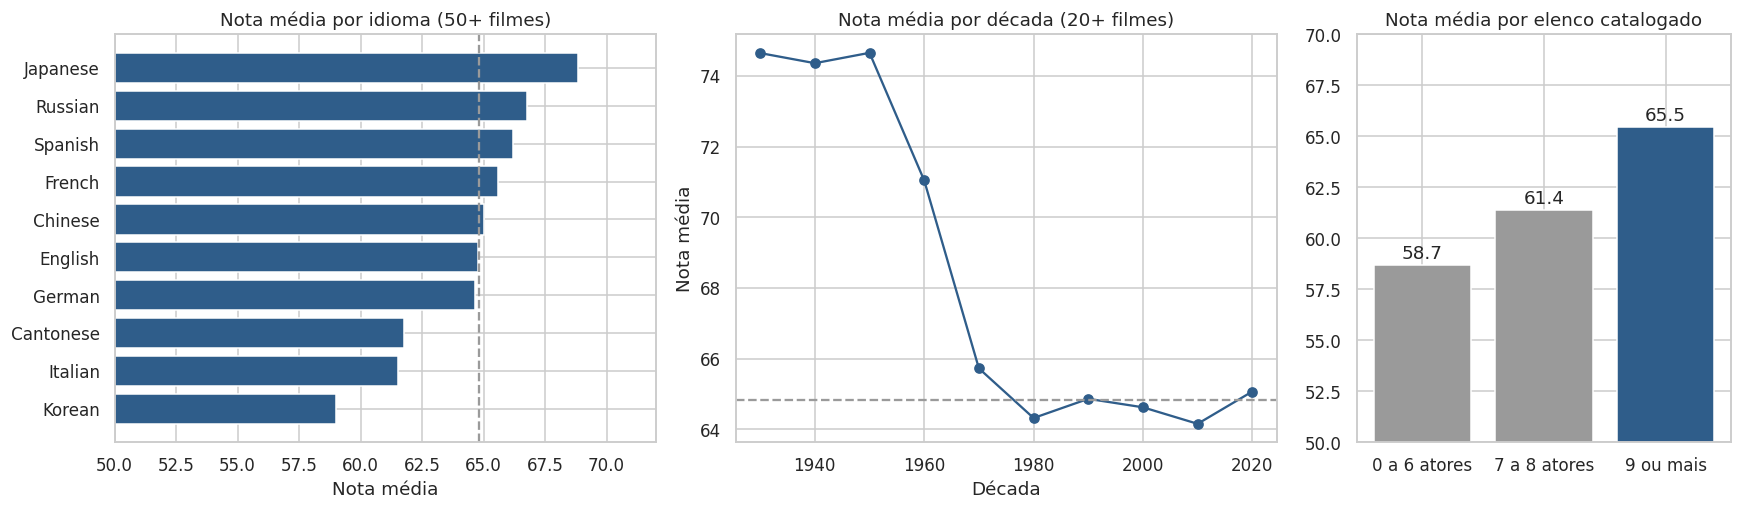

           filmes  nota_media
idioma                       
Japanese      692       68.80
Russian        60       66.80
Spanish       391       66.20
French        277       65.60
Chinese       145       65.00
English      7162       64.80
German         90       64.70
Cantonese     141       61.80
Italian       136       61.50
Korean        361       59.00


In [78]:
media_geral = df["nota"].mean()
por_idioma = (df.groupby("idioma", observed=True)["nota"].agg(filmes="size", nota_media="mean")
                .query("filmes >= 50").sort_values("nota_media"))
por_decada = df.groupby("decada")["nota"].agg(filmes="size", nota_media="mean").query("filmes >= 20")
faixas_elenco = pd.cut(df["qtd_elenco"], [-1, 6, 8, 20], labels=["0 a 6 atores", "7 a 8 atores", "9 ou mais"])
por_elenco = df.groupby(faixas_elenco, observed=True)["nota"].agg(filmes="size", nota_media="mean")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={"width_ratios": [1.3, 1.3, 0.9]})
ax[0].barh(por_idioma.index.astype(str), por_idioma["nota_media"], color=AZUL)
ax[0].axvline(media_geral, ls="--", c=CINZA); ax[0].set_xlim(50, 72)

ax[0].set_title("Nota média por idioma (50+ filmes)"); ax[0].set_xlabel("Nota média")


ax[1].plot(por_decada.index.astype(int), por_decada["nota_media"], marker="o", color=AZUL)
ax[1].axhline(media_geral, ls="--", c=CINZA)
ax[1].set_title("Nota média por década (20+ filmes)"); ax[1].set_xlabel("Década"); ax[1].set_ylabel("Nota média")



ax[2].bar(por_elenco.index.astype(str), por_elenco["nota_media"], color=[CINZA, CINZA, AZUL])
ax[2].set_ylim(50, 70); ax[2].set_title("Nota média por elenco catalogado")

for i, v in enumerate(por_elenco["nota_media"]):
    ax[2].text(i, v + 0.3, f"{v:.1f}", ha="center")
plt.tight_layout(); plt.show()


print(por_idioma.sort_values("nota_media", ascending=False).round(1).to_string())

#### **Leitura (P1)**: três coisas além do gênero aparecem com força.

- **Idioma**: filmes em japonês têm a maior média (68,8) e em coreano a menor (59,0). Mas o coreano tem uma armadilha de composição: 79% desses filmes têm romance ou drama entre os gêneros, e a base inclui muitos títulos adultos pouco conhecidos. Não é "o cinema coreano que é ruim", é o recorte de filmes coreanos que caiu nesta base.
- **Época**: filmes das décadas de 1950 e 1960 têm média acima de 71, enquanto de 1970 em diante tudo fica perto de 65. Isso é **viés de sobrevivência**: só os clássicos antigos foram catalogados, os medianos da época sumiram. Não dá para concluir que "filme antigo é melhor".
- **Visibilidade**: filmes com elenco completo catalogado (9 atores ou mais) têm média de 65,5; os com 6 ou menos, 58,7. Elenco não causa nota. O que ele mostra é que filmes mais documentados são filmes mais vistos, e filmes mais vistos têm notas mais estáveis.

**E daí?** A nota é influenciada tanto pelo filme quanto **por quem o assistiu e por quanto ele foi catalogado**. Antes de comparar notas, o cliente precisa saber se está comparando filmes com plateias do mesmo tamanho. Isso leva direto à P2.

###P2. Existe alguma coisa nesse dataset que vocês esperavam encontrar e não encontraram? O que vocês fariam se precisassem dela?

In [79]:
nota_alta = df["nota"] >= 90
print(f"Filmes com nota 90 ou mais: {nota_alta.sum()}")
print(f"  com dado financeiro confiável: {df.loc[nota_alta, 'financeiro_confiavel'].sum()}")
print(f"  com elenco incompleto (menos de 9 atores): {(df.loc[nota_alta, 'qtd_elenco'] < 9).mean():.0%}"
      f"  (na base toda: {(df['qtd_elenco'] < 9).mean():.0%})")
print(f"\nDesvio padrão da nota | com financeiro confiável: {fin['nota'].std():.1f} | sem: {df.loc[~df['financeiro_confiavel'], 'nota'].std():.1f}")
# Resumo por idioma, sem expor os títulos (vários são filmes adultos)
(df.loc[nota_alta]
   .groupby("idioma", observed=True)
   .agg(filmes=("nota", "size"), elenco_medio=("qtd_elenco", "mean"))
   .sort_values("filmes", ascending=False)
   .round(1))

Filmes com nota 90 ou mais: 20
  com dado financeiro confiável: 2
  com elenco incompleto (menos de 9 atores): 65%  (na base toda: 11%)

Desvio padrão da nota | com financeiro confiável: 8.0 | sem: 11.5


,filmes,elenco_medio
idioma,,
Korean,7,4.90
Japanese,5,8.20
English,4,8.20
Spanish,2,8.00
French,1,9.00
Malayalam,1,8.00


#### **Leitura (P2)**: dos 20 filmes com nota 90 ou mais, só **1** tem dado financeiro confiável, e 65% têm elenco incompleto (contra 11% na base toda). As notas extremas pertencem quase todas a filmes obscuros. Por idioma, a concentração é em coreano e japonês, justamente os recortes com mais filmes pouco conhecidos (P1). Isso acontece porque **falta o número de votos**: uma nota 100 dada por 3 pessoas aparece igual a uma nota 87 dada por 2 milhões.

| O que faltou | Por que importa | Como resolveríamos |
|---|---|---|
| Número de votos | Sem ele, não se sabe se a nota é confiável | Arquivo público `title.ratings` do IMDb (tem a coluna `numVotes`) |
| Diretor, roteirista, produtor | A coluna "crew" só tem atores | Diretor já trazido do Wikidata (3.6). Roteirista e produtor: propriedades P58 e P162 do Wikidata, ou o arquivo `title.crew` do IMDb |
| Identificador único | Homônimos herdaram bilheteria um do outro | `wikidata_id` já criado (3.6) para 80% da base |
| Franquia/série | Necessária para a P8 | Aproximada pelo título (seção 5); o ideal é a propriedade P179 ("parte da série") do Wikidata |
| Custo de marketing e receita líquida | ROI bruto superestima o retorno | Não é público de forma sistemática; usamos ROI só para comparar grupos |
| Tipo de obra (filme, série, show) | A base mistura formatos: *The Chosen: Season 3 - Episodes 1 & 2* é trecho de série e tem nota 100 | Filtrar pelo título não funciona (*Open Season* é filme, *Live Free or Die Hard* também). O certo é a propriedade P31 ("instância de") do Wikidata, que a consulta da 3.6 já usa para exigir "filme" |
| Duração e classificação indicativa | Afetam público potencial | Wikidata (P2047) e IMDb (`title.basics`) |

**E daí?** Na falta do número de votos, usamos o subconjunto `fin` como substituto: filme com bilheteria registrada é filme que teve público real. Por isso a P3 olha para os mais bem avaliados **dentro do `fin`**, onde a nota tem plateia por trás.

---

| O que faltou | Por que importa | Como resolveríamos |
|---|---|---|
| Número de votos | Sem ele, não se sabe se a nota é confiável | Arquivo público `title.ratings` do IMDb (tem a coluna `numVotes`) |
| Diretor, roteirista, produtor | A coluna "crew" só tem atores | Diretor já trazido do Wikidata (3.6). Roteirista e produtor: propriedades P58 e P162 do Wikidata, ou o arquivo `title.crew` do IMDb |
| Identificador único | Homônimos herdaram bilheteria um do outro | `wikidata_id` já criado (3.6) para 80% da base |
| Franquia/série | Necessária para a P8 | Aproximada pelo título (seção 5); o ideal é a propriedade P179 ("parte da série") do Wikidata |
| Custo de marketing e receita líquida | ROI bruto superestima o retorno | Não é público de forma sistemática; usamos ROI só para comparar grupos |
| Tipo de obra (filme, série, show) | A base mistura formatos: *The Chosen: Season 3 - Episodes 1 & 2* é trecho de série e tem nota 100 | Filtrar pelo título não funciona (*Open Season* é filme, *Live Free or Die Hard* também). O certo é a propriedade P31 ("instância de") do Wikidata, que a consulta da 3.6 já usa para exigir "filme" |
| Duração e classificação indicativa | Afetam público potencial | Wikidata (P2047) e IMDb (`title.basics`) |

**E daí?** Na falta do número de votos, usamos o subconjunto `fin` como substituto: filme com bilheteria registrada é filme que teve público real. Por isso a P3 olha para os mais bem avaliados **dentro do `fin`**, onde a nota tem plateia por trás.

---
### Bloco 2: aceitação do público

**P3. Filmes muito bem avaliados pelo público costumam ter algo em comum entre si, além do gênero e do orçamento?**

Para não cair na armadilha da P2, o recorte é o `fin`. "Muito bem avaliado" = os 10% de maior nota (76 ou mais). A medida é o **lift**: quantas vezes uma característica aparece mais no topo do que no resto. Lift 2 = duas vezes mais frequente.

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/03_o_que_aparece_mais_entre_os_10_mais_bem_avaliados_.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/04_o_que_aparece_mais_entre_os_10_mais_bem_avaliados_.png


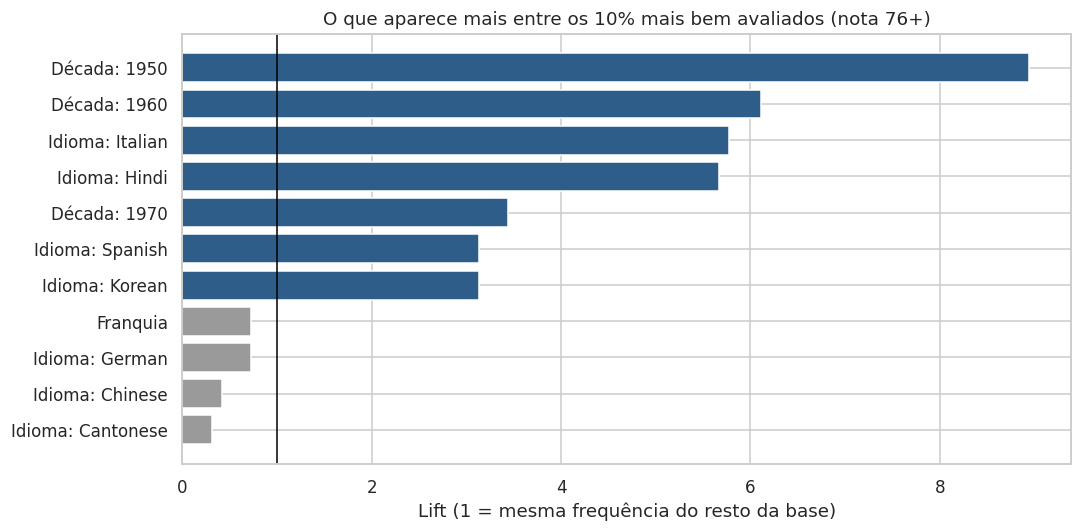

              ano     orcamento        receita  roi
top_nota                                           
Resto    2,009.00 30,000,000.00  65,514,849.50 2.38
Top 10%  2,008.00 23,000,000.00 106,933,250.50 4.53


In [80]:
corte_top = fin["nota"].quantile(0.90)
fin["top_nota"] = fin["nota"] >= corte_top

def lift(coluna, minimo=10):
    t = pd.crosstab(fin[coluna].astype(str), fin["top_nota"])
    t = t[t.sum(axis=1) >= minimo]
    prop = t / t.sum()
    return (prop[True] / prop[False]).rename("lift")

lifts = pd.concat([
    lift("idioma").rename(lambda x: f"Idioma: {x}"),
    lift("decada").rename(lambda x: f"Década: {x}"),
    lift("e_franquia").rename(lambda x: "Franquia" if x == "True" else "Filme avulso"),
]).replace(np.inf, np.nan).dropna().sort_values()
lifts = pd.concat([lifts.head(4), lifts.tail(7)])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(lifts.index, lifts.values, color=[AZUL if v > 1 else CINZA for v in lifts.values])
ax.axvline(1, c="black", lw=1)
ax.set_title(f"O que aparece mais entre os 10% mais bem avaliados (nota {corte_top:.0f}+)")
ax.set_xlabel("Lift (1 = mesma frequência do resto da base)")
plt.tight_layout(); plt.show()


print(fin.groupby("top_nota")[["ano", "orcamento", "receita", "roi"]].median().rename(index={True: "Top 10%", False: "Resto"}).round(2))

**Leitura (P3)**: os mais bem avaliados têm três coisas em comum.

- **Origem fora de Hollywood**: filmes em espanhol, italiano e japonês aparecem de 3,5 a 4 vezes mais no topo do que no resto. São poucas dezenas de filmes, mas o sinal faz sentido: são produções que chegaram ao mercado internacional justamente por terem se destacado no país de origem (*A Viagem de Chihiro*, *Os Sete Samurais*, *Cinema Paradiso*).
- **Permanência no tempo**: as décadas de 1950 a 1970 aparecem muito mais no topo. É o mesmo viés de sobrevivência da P1: o que sobrou dessas épocas é o que resistiu.
- **Retorno proporcional maior**: o ROI mediano do topo é 4,3, quase o dobro do resto (2,3), com orçamento até menor. Nota alta não garante bilheteria, mas os filmes bem avaliados rendem mais por dólar investido.

Olhando a lista do topo, outro padrão salta aos olhos: *O Poderoso Chefão*, *Um Sonho de Liberdade*, *A Lista de Schindler*, *O Senhor dos Anéis*, *Batman: O Cavaleiro das Trevas*, *A Viagem de Chihiro*. O que une esses filmes não é o elenco, é **quem os dirigiu**. É isso que a P4 testa.

**E daí?** O que une os mais bem avaliados é **identidade autoral e permanência**, não escala de produção.

**P4. O dataset tem informação sobre quem trabalhou em cada filme. Essa informação é suficiente pra explicar por que alguns filmes se destacam de forma consistente, ou falta alguma coisa?**

A informação original **não é suficiente**: a coluna `crew` só tem atores (diagnóstico 2.7). O diretor foi trazido do Wikidata (3.6).

O teste abaixo mede **quanto da variação da nota cada fator explica**. Para ser justo, todos os fatores são medidos sobre os mesmos filmes (os que têm um único diretor identificado) e só entram grupos com pelo menos 5 filmes. Também é descontado o que seria esperado por puro acaso, embaralhando os rótulos 30 vezes: sem esse desconto, qualquer fator com muitos grupos parece importante.

**P4. O dataset tem informação sobre quem trabalhou em cada filme. Essa informação é suficiente pra explicar por que alguns filmes se destacam de forma consistente, ou falta alguma coisa?**

A informação original **não é suficiente**: a coluna `crew` só tem atores (diagnóstico 2.7). O diretor foi trazido do Wikidata (3.6).

O teste abaixo mede **quanto da variação da nota cada fator explica**. Para ser justo, todos os fatores são medidos sobre os mesmos filmes (os que têm um único diretor identificado) e só entram grupos com pelo menos 5 filmes. Também é descontado o que seria esperado por puro acaso, embaralhando os rótulos 30 vezes: sem esse desconto, qualquer fator com muitos grupos parece importante.

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/05_quanto_da_variacao_da_nota_cada_fator_explica_alem.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/06_quanto_da_variacao_da_nota_cada_fator_explica_alem.png


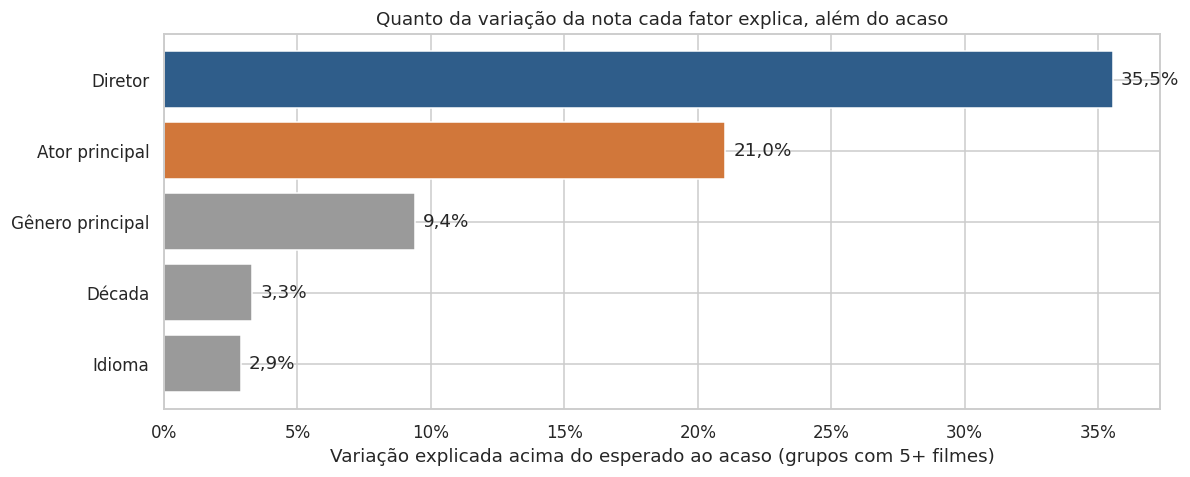

fator,filmes,grupos,explicado,esperado_ao_acaso,acima_do_acaso
Diretor,2277,308,49.0%,13.5%,35.5%
Ator principal,2881,284,31.2%,10.1%,21.0%
Gênero principal,7185,20,9.7%,0.3%,9.4%
Década,7184,11,3.4%,0.1%,3.3%
Idioma,7155,21,3.2%,0.3%,2.9%


In [81]:
def eta2(base, col):
    """Parcela da variação da nota explicada pelos grupos de 'col' (0 a 1)."""
    media = base["nota"].mean()
    g = base.groupby(col, observed=True)["nota"]
    return (g.size() * (g.mean() - media) ** 2).sum() / ((base["nota"] - media) ** 2).sum()

def poder_explicativo(base, col, nome, min_filmes=5, n_perm=30, seed=42):
    cont = base[col].value_counts()
    b = base[base[col].isin(cont[cont >= min_filmes].index)][[col, "nota"]].copy()
    b[col] = b[col].astype(str)
    real = eta2(b, col)
    rng = np.random.default_rng(seed)
    acaso = np.mean([eta2(b.assign(**{col: rng.permutation(b[col].to_numpy())}), col) for _ in range(n_perm)])
    return {"fator": nome, "filmes": len(b), "grupos": b[col].nunique(),
            "explicado": real, "esperado_ao_acaso": acaso, "acima_do_acaso": real - acaso}

base_p4 = df[df["qtd_diretores"] == 1].copy()
base_p4["diretor_unico"] = base_p4["diretores_lista"].str[0]
base_p4["ator_principal"] = base_p4["atores"].str[0]

fatores_p4 = pd.DataFrame([
    poder_explicativo(base_p4, "diretor_unico", "Diretor"),
    poder_explicativo(base_p4, "ator_principal", "Ator principal"),
    poder_explicativo(base_p4, "genero_principal", "Gênero principal"),
    poder_explicativo(base_p4, "idioma", "Idioma"),
    poder_explicativo(base_p4, "decada", "Década"),
]).sort_values("acima_do_acaso", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
ordem = fatores_p4[::-1]
ax.barh(ordem["fator"], ordem["acima_do_acaso"],
        color=[AZUL if f == "Diretor" else LARANJA if f == "Ator principal" else CINZA for f in ordem["fator"]])
for y, v in enumerate(ordem["acima_do_acaso"]):
    ax.text(v + 0.003, y, pct(v), va="center")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_title("Quanto da variação da nota cada fator explica, além do acaso")
ax.set_xlabel("Variação explicada acima do esperado ao acaso (grupos com 5+ filmes)")
plt.tight_layout(); plt.show()


fatores_p4.style.format({"explicado": "{:.1%}", "esperado_ao_acaso": "{:.1%}", "acima_do_acaso": "{:.1%}"}).hide(axis="index")

In [82]:
# Leitura gerada a partir do resultado real (não depende de preencher à mão)
r = fatores_p4.set_index("fator")
d, a = r.loc["Diretor"], r.loc["Ator principal"]
contexto = r.drop(["Diretor", "Ator principal"])["acima_do_acaso"]

if d["acima_do_acaso"] > a["acima_do_acaso"]:
    comparacao = (f"o **diretor explica {pct(d['acima_do_acaso'])}** da variação da nota além do acaso, "
                  f"contra {pct(a['acima_do_acaso'])} do ator principal. Quem constrói o filme pesa mais do que quem aparece nele.")
else:
    comparacao = (f"o ator principal explica {pct(a['acima_do_acaso'])} da variação da nota além do acaso, "
                  f"contra {pct(d['acima_do_acaso'])} do diretor. Nesta base, o rosto do filme pesa mais do que quem o dirige. "
                  "Uma ressalva: ator pode ser consequência, e não causa, porque bons atores escolhem (ou são escolhidos por) bons projetos.")

if d["acima_do_acaso"] > contexto.max():
    vs_contexto = (f"O diretor também supera todos os fatores de contexto (gênero, idioma e década explicam entre "
                   f"{pct(contexto.min())} e {pct(contexto.max())}).")
    e_dai = ("Depois do enriquecimento, quem dirige passa a explicar a nota melhor do que qualquer característica do filme em si. "
             "Para o cliente, isso significa que **a escolha do diretor é uma decisão de reputação**, e não só de custo.")
else:
    melhor = contexto.idxmax()
    vs_contexto = (f"Mas o diretor fica abaixo de {melhor.lower()} ({pct(contexto.max())}), então quem dirige "
                   "não é o fator principal da nota nesta base.")
    e_dai = ("O diretor ajuda a explicar a nota, mas não é a peça central. Para o cliente, a escolha de quem dirige "
             "deve ser combinada com as decisões de gênero e mercado, e não tratada como garantia de reputação.")

display(Markdown(f"""**Leitura (P4)**: medido sobre os mesmos {num(len(base_p4))} filmes, {comparacao}

{vs_contexto}

O que **ainda falta**: o diretor cobre {pct(df['Diretor'].notna().mean(), 0)} da base, e só entram diretores com 5 ou mais filmes ({num(d['grupos'])} nomes). Roteirista, produtor e estúdio continuam de fora, e sem o número de votos não dá para dar peso maior às notas com mais plateia.

**E daí?** A base original **não era suficiente**, porque só trazia atores. {e_dai}"""))

**Leitura (P4)**: medido sobre os mesmos 7.185 filmes, o **diretor explica 35,5%** da variação da nota além do acaso, contra 21,0% do ator principal. Quem constrói o filme pesa mais do que quem aparece nele.

O diretor também supera todos os fatores de contexto (gênero, idioma e década explicam entre 2,9% e 9,4%).

O que **ainda falta**: o diretor cobre 80% da base, e só entram diretores com 5 ou mais filmes (308 nomes). Roteirista, produtor e estúdio continuam de fora, e sem o número de votos não dá para dar peso maior às notas com mais plateia.

**E daí?** A base original **não era suficiente**, porque só trazia atores. Depois do enriquecimento, quem dirige passa a explicar a nota melhor do que qualquer característica do filme em si. Para o cliente, isso significa que **a escolha do diretor é uma decisão de reputação**, e não só de custo.

**P5. Se existisse um "padrão de sucesso" ligado às pessoas por trás dos filmes (não os atores, mas quem os fez), como vocês descobririam isso com os dados que têm e com os que não têm?**

**Método:**
1. Calcular a **nota esperada** de cada filme pelo contexto: a média do seu gênero principal na sua década. Assim, um diretor de terror não é punido por trabalhar num gênero que recebe notas mais baixas.
2. Calcular o **resíduo**: nota real menos nota esperada. Positivo = o filme superou o esperado.
3. Para cada diretor com 5 ou mais filmes, medir a média do resíduo e **em quantos filmes ele superou o esperado** (consistência). Em codireções, cada diretor recebe o crédito.
4. Cruzar com o ROI mediano no `fin`, para separar quem entrega reputação de quem entrega reputação **e** retorno.

In [83]:
# Nota esperada = média dos OUTROS filmes do mesmo gênero e década (o próprio filme não entra na conta)
grupo = df.groupby(["genero_principal", "decada"], observed=True)["nota"]
soma, n = grupo.transform("sum"), grupo.transform("size")
df["nota_esperada"] = np.where(n > 1, (soma - df["nota"]) / (n - 1), np.nan)
df["residuo"] = df["nota"] - df["nota_esperada"]

por_diretor = df[["id", "titulo", "residuo", "roi", "financeiro_confiavel", "diretores_lista"]].explode("diretores_lista")
por_diretor = por_diretor.dropna(subset=["diretores_lista"]).rename(columns={"diretores_lista": "diretor"})

ranking = (por_diretor.groupby("diretor")
           .agg(filmes=("id", "size"),
                residuo_medio=("residuo", "mean"),
                acima_do_esperado=("residuo", lambda s: (s.dropna() > 0).mean()),
                filmes_com_financeiro=("financeiro_confiavel", "sum"),
                roi_mediano=("roi", "median"))
           .query("filmes >= 5")
           .sort_values("residuo_medio", ascending=False))

print(f"Diretores com 5+ filmes: {len(ranking)}")
ranking.head(15).style.format({"residuo_medio": "{:+.1f}", "acima_do_esperado": "{:.0%}", "roi_mediano": "{:.1f}"})

Diretores com 5+ filmes: 384


,filmes,residuo_medio,acima_do_esperado,filmes_com_financeiro,roi_mediano
diretor,,,,,
Christopher Nolan,10,+13.4,100%,10,3.7
Stanley Kubrick,9,+13.3,100%,6,2.1
Hayao Miyazaki,5,+13.0,100%,4,6.9
Denis Villeneuve,6,+12.9,100%,5,2.5
Bong Joon-ho,6,+12.0,100%,2,2.8
Peter Jackson,11,+11.4,100%,10,3.8
Akira Kurosawa,8,+11.1,100%,1,0.2
Wes Anderson,9,+11.1,100%,8,1.9
Edgar Wright,6,+11.1,100%,6,3.7


Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/07_diretores_com_5_filmes_reputacao_acima_do_esperado.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/08_diretores_com_5_filmes_reputacao_acima_do_esperado.png


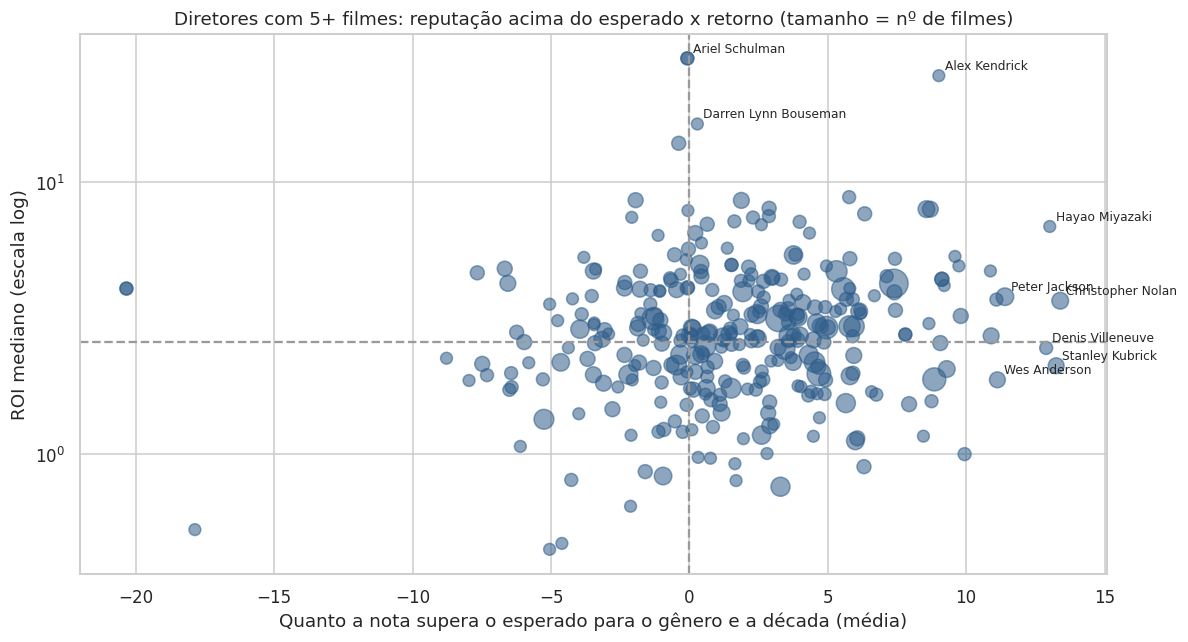

**Leitura (P5)**: dos 384 diretores com 5 ou mais filmes, **116** superaram a nota esperada em pelo menos 80% dos seus filmes. Por pura sorte, o esperado seria cerca de 49. Encontrar 2,4 vezes mais do que o acaso indica um **padrão real**: há diretores que acertam com frequência, já descontados o gênero e a época.

No cruzamento com dinheiro, **122** de 309 diretores (com 3 ou mais filmes no `fin`) ficam no quadrante superior direito: nota acima do esperado **e** ROI acima da mediana (2,6). Os de maior nota acima do esperado nesse grupo: Christopher Nolan, Hayao Miyazaki, Peter Jackson, Edgar Wright, Francis Ford Coppola.

**Com os dados que temos** (depois do enriquecimento), dá para medir quem entrega consistência. **Com os que não temos**, o passo seguinte seria:
- trazer roteirista (P58), produtor (P162) e estúdio (P272) do Wikidata usando o `wikidata_id`, e repetir o mesmo teste para cada função;
- trazer o número de votos (`title.ratings` do IMDb) para dar mais peso às notas com mais plateia;
- olhar a **trajetória**: um diretor que melhora a cada filme vale mais do que a média dele sugere.

**E daí?** Existe um padrão de sucesso ligado a quem faz o filme, e ele é mensurável. A recomendação prática é montar uma **lista de diretores com histórico consistente**, separando quem traz reputação de quem traz reputação e retorno.

In [84]:
graf = ranking[ranking["filmes_com_financeiro"] >= 3].copy()
roi_ref = fin["roi"].median()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(graf["residuo_medio"], graf["roi_mediano"], s=graf["filmes"] * 12, alpha=0.55, color=AZUL)
ax.axvline(0, c=CINZA, ls="--"); ax.axhline(roi_ref, c=CINZA, ls="--")

ax.set_yscale("log")
destaques = pd.concat([graf.nlargest(6, "residuo_medio"), graf.nlargest(4, "roi_mediano")]).drop_duplicates()
for nome, linha in destaques.iterrows():
    ax.annotate(nome, (linha["residuo_medio"], linha["roi_mediano"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Quanto a nota supera o esperado para o gênero e a década (média)")
ax.set_ylabel("ROI mediano (escala log)")
ax.set_title("Diretores com 5+ filmes: reputação acima do esperado x retorno (tamanho = nº de filmes)")
plt.tight_layout(); plt.show()


# Quantos diretores passariam no critério por pura sorte? Embaralha os resíduos entre os filmes e repete o cálculo.
def contar_consistentes(base):
    g = base.groupby("diretor")["residuo"].agg(filmes="size", media="mean", acima=lambda s: (s.dropna() > 0).mean())
    g = g[g["filmes"] >= 5]
    return ((g["acima"] >= 0.8) & (g["media"] > 0)).sum()

rng = np.random.default_rng(42)
por_filme = df[["id", "residuo"]]
ao_acaso = np.mean([
    contar_consistentes(por_diretor.drop(columns="residuo").merge(
        por_filme.assign(residuo=rng.permutation(por_filme["residuo"].to_numpy())), on="id"))
    for _ in range(20)])

consistentes = ranking[(ranking["acima_do_esperado"] >= 0.8) & (ranking["residuo_medio"] > 0)]
completos = graf[(graf["residuo_medio"] > 0) & (graf["roi_mediano"] > roi_ref)]
razao = len(consistentes) / ao_acaso if ao_acaso else float("inf")

if razao >= 1.5:
    padrao = (f"Por pura sorte, o esperado seria cerca de {num(ao_acaso)}. Encontrar {num(razao, 1)} vezes mais do que o acaso "
              "indica um **padrão real**: há diretores que acertam com frequência, já descontados o gênero e a época.")
    e_dai = ("Existe um padrão de sucesso ligado a quem faz o filme, e ele é mensurável. A recomendação prática é montar uma "
             "**lista de diretores com histórico consistente**, separando quem traz reputação de quem traz reputação e retorno.")
else:
    padrao = (f"Por pura sorte, o esperado seria cerca de {num(ao_acaso)}. Como o número real fica perto do acaso, "
              "**não dá para afirmar um padrão** só com o diretor: a consistência de muitos deles pode ser sorte.")
    e_dai = ("Com o diretor sozinho, o padrão não se sustenta. É preciso trazer as outras funções (roteiro, produção, estúdio) "
             "e o número de votos antes de recomendar nomes ao cliente.")

display(Markdown(f"""**Leitura (P5)**: dos {num(len(ranking))} diretores com 5 ou mais filmes, **{num(len(consistentes))}** superaram a nota esperada em pelo menos 80% dos seus filmes. {padrao}

No cruzamento com dinheiro, **{num(len(completos))}** de {num(len(graf))} diretores (com 3 ou mais filmes no `fin`) ficam no quadrante superior direito: nota acima do esperado **e** ROI acima da mediana ({num(roi_ref, 1)}). Os de maior nota acima do esperado nesse grupo: {", ".join(completos.nlargest(5, "residuo_medio").index)}.

**Com os dados que temos** (depois do enriquecimento), dá para medir quem entrega consistência. **Com os que não temos**, o passo seguinte seria:
- trazer roteirista (P58), produtor (P162) e estúdio (P272) do Wikidata usando o `wikidata_id`, e repetir o mesmo teste para cada função;
- trazer o número de votos (`title.ratings` do IMDb) para dar mais peso às notas com mais plateia;
- olhar a **trajetória**: um diretor que melhora a cada filme vale mais do que a média dele sugere.

**E daí?** {e_dai}"""))

---
### Bloco 3: retorno financeiro x aceitação

**P6. Os filmes que mais faturaram são também os mais bem avaliados pelo público? Sempre?**

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/09_receita_x_nota_as_linhas_separam_os_25_que_mais_fa.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/10_receita_x_nota_as_linhas_separam_os_25_que_mais_fa.png


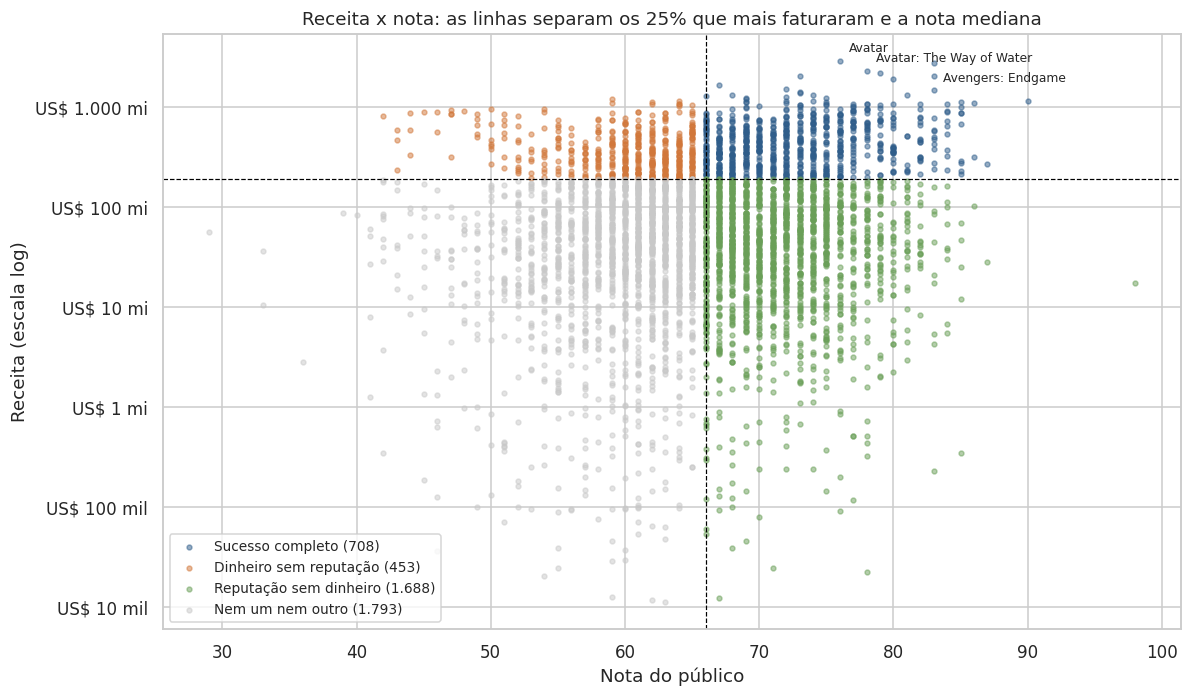

Correlação (Spearman) entre nota e receita: 0.14
Entre os 10% que mais faturaram: 24% também estão entre os 10% de maior nota
                                 144 de 465 têm nota abaixo da mediana


In [85]:
q75_receita = fin["receita"].quantile(0.75)
mediana_nota = fin["nota"].median()

def quadrante(linha):
    dinheiro, reputacao = linha["receita"] >= q75_receita, linha["nota"] >= mediana_nota
    if dinheiro and reputacao: return "Sucesso completo"
    if dinheiro: return "Dinheiro sem reputação"
    if reputacao: return "Reputação sem dinheiro"
    return "Nem um nem outro"

fin["quadrante"] = fin.apply(quadrante, axis=1)
cores_q = {"Sucesso completo": AZUL, "Dinheiro sem reputação": LARANJA,
           "Reputação sem dinheiro": "#6a9f58", "Nem um nem outro": "#c8c8c8"}

fig, ax = plt.subplots(figsize=(11, 6.5))
for nome, cor in cores_q.items():
    parte = fin[fin["quadrante"] == nome]
    ax.scatter(parte["nota"], parte["receita"], s=10, alpha=0.5, color=cor, label=f"{nome} ({num(len(parte))})")
ax.set_yscale("log")
ax.axhline(q75_receita, c="black", lw=0.8, ls="--"); ax.axvline(mediana_nota, c="black", lw=0.8, ls="--")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"US$ {num(v/1e6)} mi" if v >= 1e6 else f"US$ {num(v/1e3)} mil"))
for (_, l), dy in zip(fin.nlargest(3, "receita").iterrows(), [6, -12, 6]):
    ax.annotate(l["titulo"], (l["nota"], l["receita"]), fontsize=8, xytext=(6, dy), textcoords="offset points")
ax.set_xlabel("Nota do público"); ax.set_ylabel("Receita (escala log)")

ax.set_title("Receita x nota: as linhas separam os 25% que mais faturaram e a nota mediana")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()


rho = fin[["nota", "receita"]].corr(method="spearman").iloc[0, 1]
top10_receita = fin["receita"] >= fin["receita"].quantile(0.90)
print(f"Correlação (Spearman) entre nota e receita: {rho:.2f}")
print(f"Entre os 10% que mais faturaram: {(fin.loc[top10_receita, 'nota'] >= fin['nota'].quantile(0.90)).mean():.0%} também estão entre os 10% de maior nota")
print(f"                                 {(fin.loc[top10_receita, 'nota'] < mediana_nota).sum()} de {top10_receita.sum()} têm nota abaixo da mediana")

**Leitura (P6)**: às vezes, mas nem perto de sempre. A correlação entre nota e receita é fraca (0,19). Os maiores sucessos de bilheteria (Avatar, Vingadores: Ultimato, Titanic) são bem avaliados, mas basta descer um pouco no ranking para a relação se desfazer: entre os 10% que mais faturaram, só 26% também estão entre os 10% de maior nota, e 105 de 384 ficam abaixo da nota mediana.

**O gráfico também mostra o caso inverso, que é o mais numeroso:** 1.326 filmes têm nota acima da mediana e receita fora do topo. Reputação sem dinheiro é muito mais comum do que dinheiro sem reputação.

**E daí?** Nota e receita são dois objetivos diferentes, não um só. O cliente precisa decidir qual dos dois está comprando em cada projeto, porque otimizar um não entrega o outro automaticamente.



**P7. O que explicaria um filme (ou uma sequência de filmes) que fatura muito, mas recebe uma nota mediana ou baixa?**

,filmes,franquia,orcamento_mediano,roi_mediano
quadrante,,,,
Sucesso completo,708,23%,"US$ 93,100,000",4.99
Dinheiro sem reputação,453,20%,"US$ 107,200,000",3.73
Reputação sem dinheiro,1688,7%,"US$ 18,000,000",2.34
Nem um nem outro,1793,11%,"US$ 25,000,000",1.60


Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/11_generos_nota_x_retorno_tamanho_no_de_filmes_no_sub.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/12_generos_nota_x_retorno_tamanho_no_de_filmes_no_sub.png


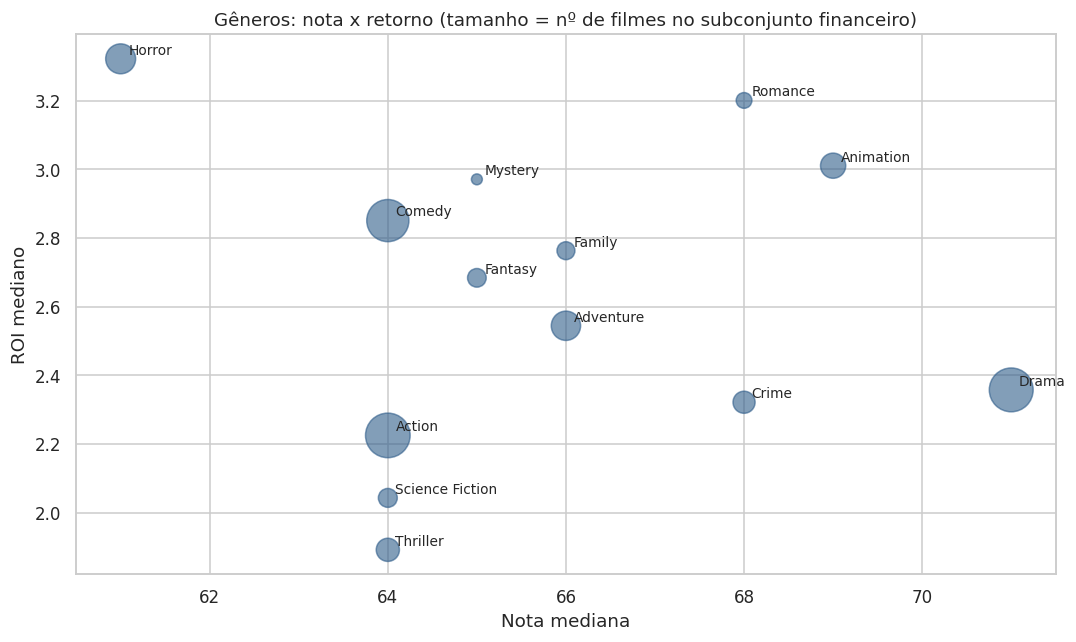

,titulo,ano,nota,receita,e_franquia
1859,Blue Thermal,2022,59.00,"1,220,832,375.00",False
1926,Minions,2015,64.00,"1,157,271,759.00",True
5069,Transformers: Dark of the Moon,2011,62.00,"1,123,794,079.00",True
491,Transformers: Age of Extinction,2014,59.00,"1,104,054,072.00",True
3024,Ice Age: The Great Egg-Scapade,2016,64.00,"1,084,895,103.00",True
4150,Un alibi,2022,62.00,"1,084,813,489.00",False
959,Star Wars: The Rise of Skywalker,2019,64.00,"1,072,767,997.00",True
287,Pirates of the Caribbean: On Stranger Tides,2011,65.00,"1,045,713,802.00",True
1445,Despicable Me 3,2017,64.00,"1,032,809,657.00",True
8839,Death Ship,1980,54.00,"973,467,314.00",False


In [86]:
perfil = (fin.groupby("quadrante")
          .agg(filmes=("nota", "size"),
               franquia=("e_franquia", "mean"),
               orcamento_mediano=("orcamento", "median"),
               roi_mediano=("roi", "median"))
          .loc[list(cores_q)])
display(perfil.style.format({"franquia": "{:.0%}", "orcamento_mediano": "US$ {:,.0f}", "roi_mediano": "{:.2f}"}))

por_genero = (fin.groupby("genero_principal", observed=True)
              .agg(filmes=("nota", "size"), nota_mediana=("nota", "median"),
                   roi_mediano=("roi", "median"), com_prejuizo=("roi", lambda s: (s < 1).mean()))
              .query("filmes >= 40").sort_values("roi_mediano"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(por_genero["nota_mediana"], por_genero["roi_mediano"], s=por_genero["filmes"], alpha=0.6, color=AZUL)
for nome, l in por_genero.iterrows():
    ax.annotate(nome, (l["nota_mediana"], l["roi_mediano"]), fontsize=9, xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("Nota mediana"); ax.set_ylabel("ROI mediano")

ax.set_title("Gêneros: nota x retorno (tamanho = nº de filmes no subconjunto financeiro)")
plt.tight_layout(); plt.show()


fin[fin["quadrante"] == "Dinheiro sem reputação"].nlargest(10, "receita")[["titulo", "ano", "nota", "receita", "e_franquia"]]

**Leitura (P7)**: o grupo "dinheiro sem reputação" tem um perfil bem definido:

- **É franquia**: 26% dos filmes desse grupo são de franquia, contra 6% no grupo "reputação sem dinheiro". *Transformers*, *Minions*, *Piratas do Caribe* e *Star Wars: A Ascensão Skywalker* lideram a lista. (A detecção de franquia pelo título deixa passar casos como *007 Contra Spectre* e *Batman vs Superman*, então a proporção real é ainda maior.)
- **É caro**: orçamento mediano de US\$ 100 milhões, cinco vezes o do grupo "reputação sem dinheiro" (US\$ 20 milhões).
- **O gênero muda a equação**: terror tem a **menor** nota mediana (62) e o **maior** ROI mediano (3,1). Drama tem a maior nota (71) e um dos menores retornos.

**Por que isso acontece?** O ingresso é comprado **antes** de o público ver o filme, e a nota é dada **depois**. O que vende o ingresso é a expectativa: marca conhecida, personagem querido, lançamento em muitas salas, marketing pesado. A nota mede se a expectativa foi cumprida. Uma franquia vende pela promessa, mesmo que o filme não a cumpra. O terror tem um público fiel que vai ao cinema pela experiência, e o custo baixo faz qualquer bilheteria média virar retorno alto.

Um alerta sobre a qualidade do dado: *Frenemies* (2012) e *When Love Is Lust* (1973) apareciam com receita perto de US\$ 1 bilhão, o que não é plausível. Eles passaram nos testes automáticos da 3.8 e foram excluídos manualmente, o que mostra que o filtro reduz o ruído, mas não o elimina. Os padrões acima se sustentam porque são medianas de centenas de filmes, e não dependem de casos isolados.

**E daí?** Faturar com nota mediana **não é acidente, é modelo de negócio**: marca forte mais distribuição ampla. O risco é que esse modelo consome reputação, como a P8 mostra.

**P8. Filmes que fazem parte de uma mesma série/continuação se comportam de forma parecida entre si em termos de nota e receita, ou cada um é um caso isolado?**

Duas medidas: (1) a dispersão **dentro** de cada franquia, comparada com a de grupos sorteados ao acaso do mesmo tamanho; (2) como nota e receita mudam do primeiro filme para os seguintes.

Nota    | desvio dentro da franquia: 6.4 pontos | entre filmes sorteados: 8.8 pontos
Receita | variação típica dentro da franquia: 2.0x | entre filmes sorteados: 4.0x
(96 franquias com 3+ filmes no subconjunto financeiro)
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/13_nota_diferenca_para_o_1o_filme_da_franquia_mediana.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/14_nota_diferenca_para_o_1o_filme_da_franquia_mediana.png


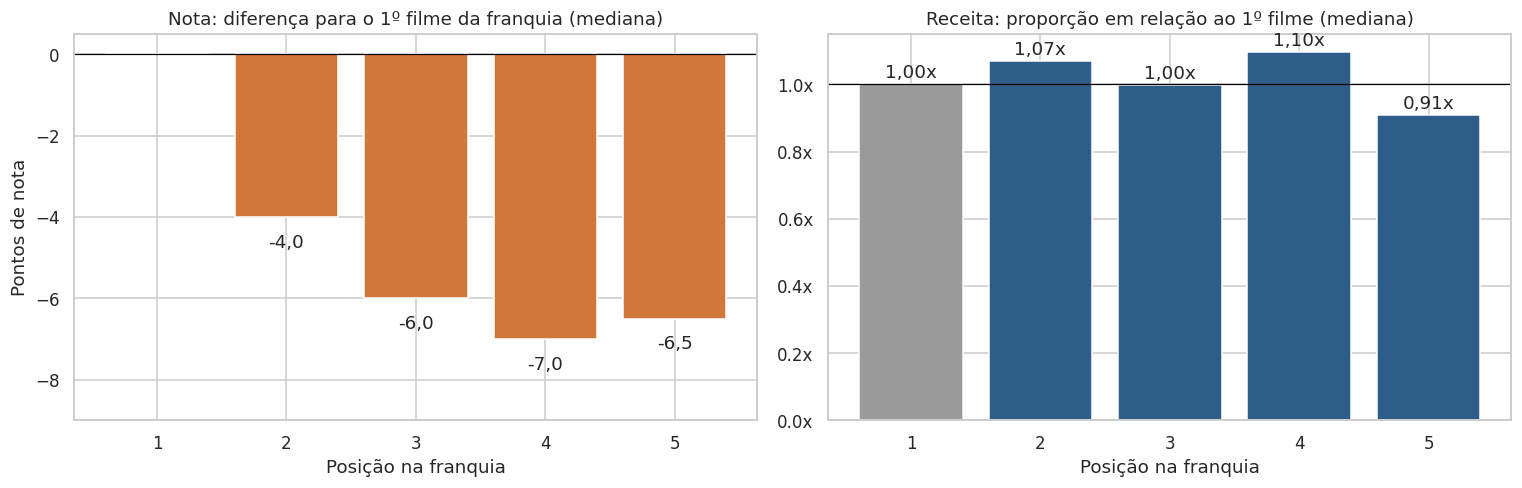

,filmes,nota,receita
ordem,,,
1,96,0.00,1.00
2,96,-4.00,1.07
3,96,-6.00,1.00
4,41,-7.00,1.10
5,20,-6.50,0.91


In [87]:
rng = np.random.default_rng(42)
def dispersao(base, col, valor):
    return base.groupby(col)[valor].std().mean()

fr_nota = df[df["e_franquia"]]
fr_fin = fin[fin["e_franquia"]].copy()
fr_fin["log_receita"] = np.log10(fr_fin["receita"])
fr_fin = fr_fin[fr_fin["franquia_chave"].map(fr_fin["franquia_chave"].value_counts()) >= 3]

nota_dentro = dispersao(fr_nota, "franquia_chave", "nota")
nota_acaso = np.mean([dispersao(fr_nota.assign(k=rng.permutation(fr_nota["franquia_chave"].to_numpy())), "k", "nota") for _ in range(200)])
rec_dentro = dispersao(fr_fin, "franquia_chave", "log_receita")
rec_acaso = np.mean([dispersao(fr_fin.assign(k=rng.permutation(fr_fin["franquia_chave"].to_numpy())), "k", "log_receita") for _ in range(200)])

print(f"Nota    | desvio dentro da franquia: {nota_dentro:.1f} pontos | entre filmes sorteados: {nota_acaso:.1f} pontos")
print(f"Receita | variação típica dentro da franquia: {10**rec_dentro:.1f}x | entre filmes sorteados: {10**rec_acaso:.1f}x")
print(f"({fr_fin['franquia_chave'].nunique()} franquias com 3+ filmes no subconjunto financeiro)")

# Evolução ao longo da série
seq = fr_fin.sort_values("data_lancamento").copy()
seq["ordem"] = seq.groupby("franquia_chave").cumcount() + 1
seq["receita_vs_primeiro"] = seq["receita"] / seq.groupby("franquia_chave")["receita"].transform("first")
seq["nota_vs_primeiro"] = seq["nota"] - seq.groupby("franquia_chave")["nota"].transform("first")
evolucao = (seq[seq["ordem"] <= 5].groupby("ordem")
            .agg(filmes=("nota", "size"), nota=("nota_vs_primeiro", "median"), receita=("receita_vs_primeiro", "median")))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
ax[0].bar(evolucao.index, evolucao["nota"], color=[CINZA] + [LARANJA] * (len(evolucao) - 1))
ax[0].axhline(0, c="black", lw=0.8)
ax[0].set_title("Nota: diferença para o 1º filme da franquia (mediana)")
ax[0].set_xlabel("Posição na franquia"); ax[0].set_ylabel("Pontos de nota")

ax[0].set_ylim(evolucao["nota"].min() - 2, 0.5)
ax[1].bar(evolucao.index, evolucao["receita"], color=[CINZA] + [AZUL] * (len(evolucao) - 1))
ax[1].axhline(1, c="black", lw=0.8)
ax[1].set_title("Receita: proporção em relação ao 1º filme (mediana)")
ax[1].set_xlabel("Posição na franquia"); ax[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.1f}x"))

for eixo in ax: eixo.set_xticks(evolucao.index)
for i, v in zip(evolucao.index, evolucao["nota"]):
    if i > 1: ax[0].text(i, v - 0.4, num(v, 1), ha="center", va="top")
for i, v in zip(evolucao.index, evolucao["receita"]):
    ax[1].text(i, v + 0.02, f"{num(v, 2)}x", ha="center")
plt.tight_layout(); plt.show()

evolucao.round(2)

**Leitura (P8)**: filmes da mesma franquia **se parecem entre si, e se parecem muito mais em receita do que em nota**.

- **Receita**: dentro de uma franquia, a receita varia tipicamente 1,7 vez; entre filmes sorteados ao acaso, 3,4 vezes. A franquia praticamente "herda" a bilheteria.
- **Nota**: o desvio dentro da franquia (6,5 pontos) é menor que o de filmes sorteados (8,8), mas a diferença é bem menor do que na receita.
- **Ao longo da série**: a partir do segundo filme, a nota cai de 4 a 5 pontos em relação ao primeiro e **não se recupera** (no quinto filme a queda chega a 8,5 pontos, mas são só 14 casos). A receita, não: do segundo ao quinto filme, ela fica entre 0,91x e 1,18x a do primeiro.

**E daí?** Essa é a explicação mais clara para a tensão do cliente: **a franquia transfere dinheiro de um filme para o próximo, mas não transfere qualidade**. A continuação é a aposta financeira mais previsível da base, e é também onde a reputação se desgasta. O risco não aparece na bilheteria do filme atual, aparece no valor da marca para os próximos.

**P9. É natural pensar que quanto maior o orçamento de um filme, melhor deveria ser a nota que ele recebe do público. Mas os dados confirmam isso? Qual é essa relação, na prática, e por que ela se comporta desse jeito?**

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/15_nota_mediana_praticamente_nao_muda.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/16_nota_mediana_praticamente_nao_muda.png


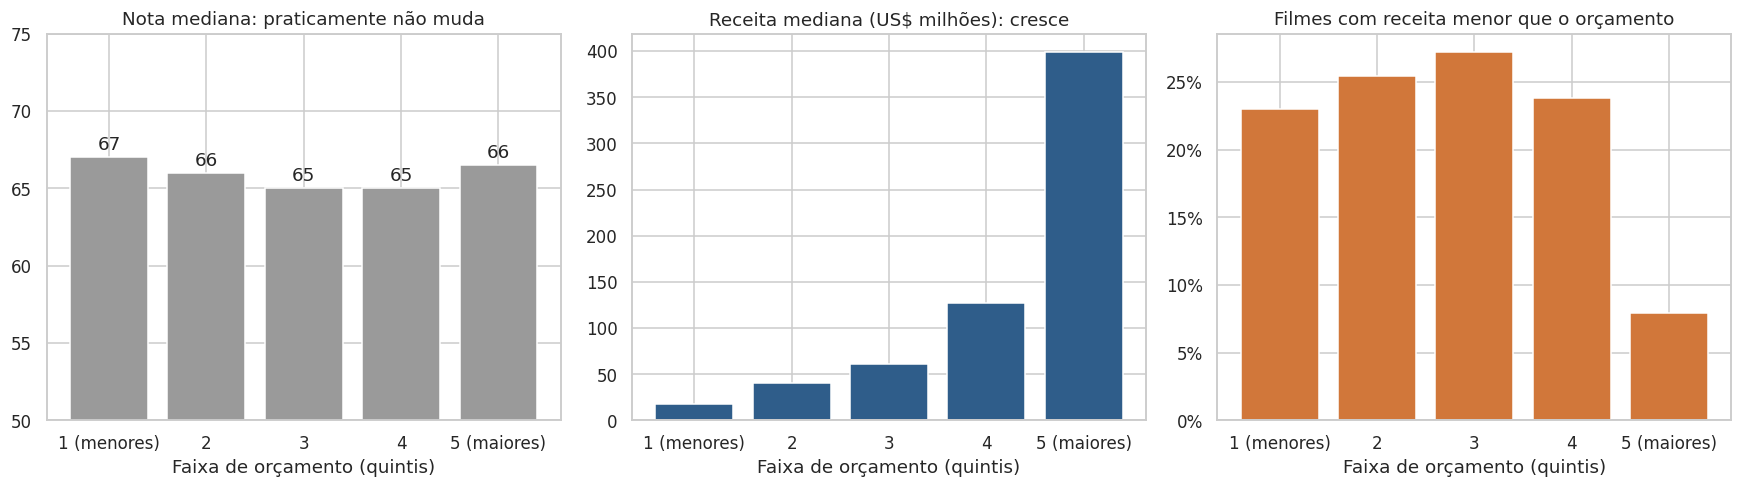

Correlação (Spearman) orçamento x nota: -0.04
Correlação (Spearman) orçamento x receita: 0.70


,filmes,orcamento_mediano,nota_mediana,receita_mediana,roi_mediano,com_prejuizo
faixa_orcamento,,,,,,
1 (menores),1027,"US$ 5,000,000",67,"US$ 17,768,757",3.50,23%
2,848,"US$ 15,600,000",66,"US$ 40,583,500",2.61,25%
3,1029,"US$ 30,000,000",65,"US$ 60,709,968",2.02,27%
4,852,"US$ 60,000,000",65,"US$ 127,146,368",2.15,24%
5 (maiores),886,"US$ 125,000,000",66,"US$ 398,716,440",3.10,8%


In [88]:
fin["faixa_orcamento"] = pd.qcut(fin["orcamento"], 5, labels=["1 (menores)", "2", "3", "4", "5 (maiores)"])
faixas = (fin.groupby("faixa_orcamento", observed=True)
          .agg(filmes=("nota", "size"),
               orcamento_mediano=("orcamento", "median"),
               nota_mediana=("nota", "median"),
               receita_mediana=("receita", "median"),
               roi_mediano=("roi", "median"),
               com_prejuizo=("roi", lambda s: (s < 1).mean())))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
x = faixas.index.astype(str)
ax[0].bar(x, faixas["nota_mediana"], color=CINZA); ax[0].set_ylim(50, 75)

ax[0].set_title("Nota mediana: praticamente não muda")
ax[1].bar(x, faixas["receita_mediana"] / 1e6, color=AZUL)
ax[1].set_title("Receita mediana (US$ milhões): cresce")
ax[2].bar(x, faixas["com_prejuizo"], color=LARANJA)
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax[2].set_title("Filmes com receita menor que o orçamento")
for eixo in ax: eixo.set_xlabel("Faixa de orçamento (quintis)")
for i, v in enumerate(faixas["nota_mediana"]): ax[0].text(i, v + 0.5, f"{v:.0f}", ha="center")
plt.tight_layout(); plt.show()


corr = fin[["orcamento", "nota", "receita"]].corr(method="spearman")
print(f"Correlação (Spearman) orçamento x nota: {corr.loc['orcamento', 'nota']:.2f}")
print(f"Correlação (Spearman) orçamento x receita: {corr.loc['orcamento', 'receita']:.2f}")
faixas.style.format({"orcamento_mediano": "US$ {:,.0f}", "receita_mediana": "US$ {:,.0f}",
                     "roi_mediano": "{:.2f}", "com_prejuizo": "{:.0%}", "nota_mediana": "{:.0f}"})

**Leitura (P9)**: **os dados não confirmam.** A correlação entre orçamento e nota é zero (0,00). Dos filmes de US\$ 7 milhões aos de US\$ 122 milhões (medianas da menor e da maior faixa), a nota mediana fica entre 65 e 67. Já a correlação entre orçamento e receita é forte (0,67).

O orçamento compra outra coisa: **segurança**. Na faixa de maior orçamento, só 10% dos filmes faturaram menos do que custaram; nas outras faixas, de 23% a 27%. Os filmes mais baratos têm o maior ROI mediano (3,3), mas também o maior risco.

**Por que se comporta assim?** Dinheiro paga escala: efeitos visuais, astros, número de salas, marketing. Tudo isso aumenta quantas pessoas vão ver o filme, não o quanto elas gostam dele. A nota depende de roteiro, direção e execução, que custam pouco em proporção ao orçamento total. Além disso, cada pessoa avalia o filme em relação à expectativa que tinha, e filmes caros criam expectativas altas.

**E daí?** Para o cliente: **orçamento alto é seguro de bilheteria, não de reputação**. Se o objetivo for reputação, o investimento certo não é aumentar o orçamento, é escolher quem dirige (P4 e P5).

## Síntese: o que move a nota e o que move a receita

**P9 (complemento). Elenco e orçamento: o que um protagonista conhecido compra?**

A base não tem cachê nem fama dos atores. Como medida aproximada de "nome estabelecido", uso a **experiência do ator principal**: em quantos filmes da base ele aparece. O tamanho do elenco não serve para isso, porque a base guarda no máximo 9 atores por filme e essa coluna mede o quanto o filme foi catalogado.

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/17_dinheiro_cresce_com_a_experiencia_do_protagonista.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/18_dinheiro_cresce_com_a_experiencia_do_protagonista.png


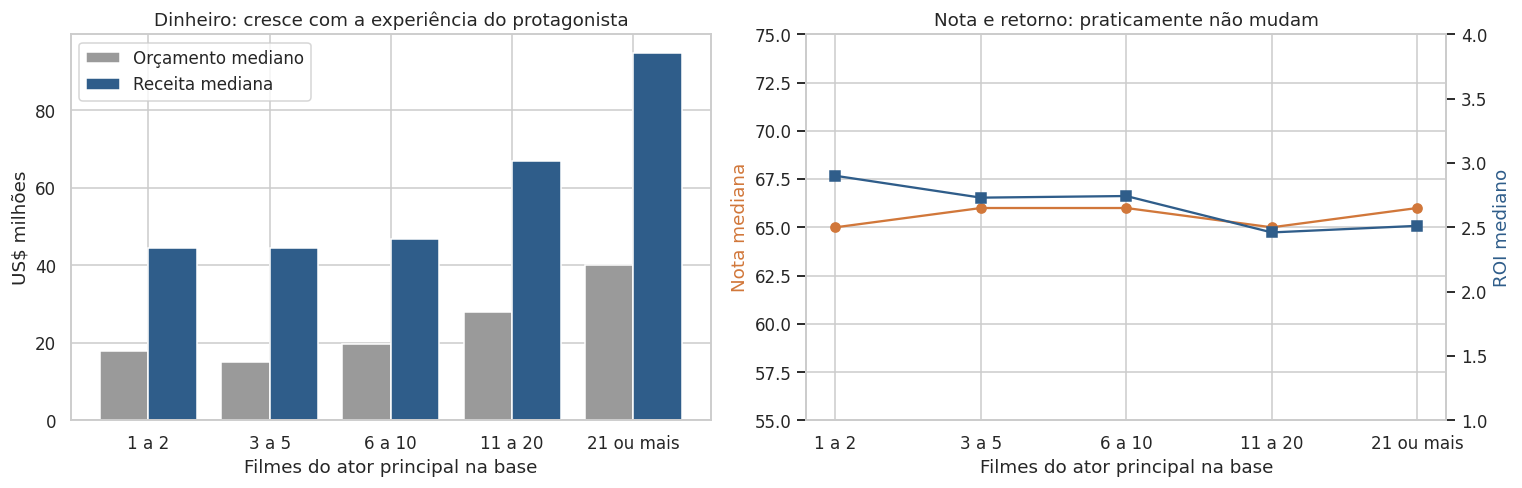

Correlação (Spearman) da experiência do ator principal com:
orçamento    0.23
receita      0.14
nota         0.04
roi         -0.05

Tamanho do elenco catalogado x orçamento: -0.08


,filmes,orcamento_mediano,receita_mediana,nota_mediana,roi_mediano
faixa_experiencia,,,,,
1 a 2,500,"US$ 18,000,000","US$ 44,402,466",65,2.90
3 a 5,457,"US$ 15,000,000","US$ 44,451,470",66,2.73
6 a 10,615,"US$ 19,600,000","US$ 46,754,020",66,2.74
11 a 20,1104,"US$ 28,000,000","US$ 66,798,748",65,2.46
21 ou mais,1962,"US$ 40,000,000","US$ 94,853,888",66,2.51


In [89]:
filmes_por_ator = df["atores"].explode().value_counts()
fin["ator_principal"] = fin["atores"].str[0]
fin["experiencia_ator"] = fin["ator_principal"].map(filmes_por_ator)
fin["faixa_experiencia"] = pd.cut(fin["experiencia_ator"], [0, 2, 5, 10, 20, 1000],
                                  labels=["1 a 2", "3 a 5", "6 a 10", "11 a 20", "21 ou mais"])

astro = (fin.groupby("faixa_experiencia", observed=True)
         .agg(filmes=("nota", "size"),
              orcamento_mediano=("orcamento", "median"),
              receita_mediana=("receita", "median"),
              nota_mediana=("nota", "median"),
              roi_mediano=("roi", "median")))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
x = astro.index.astype(str)
largura = 0.4
pos = np.arange(len(x))
ax[0].bar(pos - largura / 2, astro["orcamento_mediano"] / 1e6, largura, color=CINZA, label="Orçamento mediano")
ax[0].bar(pos + largura / 2, astro["receita_mediana"] / 1e6, largura, color=AZUL, label="Receita mediana")
ax[0].set_xticks(pos, x); ax[0].legend()

ax[0].set_title("Dinheiro: cresce com a experiência do protagonista")
ax[0].set_ylabel("US$ milhões"); ax[0].set_xlabel("Filmes do ator principal na base")


ax2 = ax[1].twinx()
ax[1].plot(x, astro["nota_mediana"], marker="o", color=LARANJA, label="Nota mediana")
ax2.plot(x, astro["roi_mediano"], marker="s", color=AZUL, label="ROI mediano")
ax[1].set_ylim(55, 75); ax2.set_ylim(1, 4); ax2.grid(False)


ax[1].set_ylabel("Nota mediana", color=LARANJA); ax2.set_ylabel("ROI mediano", color=AZUL)

ax[1].set_title("Nota e retorno: praticamente não mudam")
ax[1].set_xlabel("Filmes do ator principal na base")
plt.tight_layout(); plt.show()


corr_astro = fin[["experiencia_ator", "orcamento", "receita", "nota", "roi"]].corr(method="spearman")["experiencia_ator"]
print("Correlação (Spearman) da experiência do ator principal com:")
print(corr_astro.drop("experiencia_ator").rename({"orcamento": "orçamento"}).round(2).to_string())
print(f"\nTamanho do elenco catalogado x orçamento: {fin[['qtd_elenco', 'orcamento']].corr(method='spearman').iloc[0, 1]:.2f}")
astro.style.format({"orcamento_mediano": "US$ {:,.0f}", "receita_mediana": "US$ {:,.0f}",
                    "nota_mediana": "{:.0f}", "roi_mediano": "{:.2f}"})

**Leitura (complemento da P9)**: quando o protagonista é um nome estabelecido (21 filmes ou mais na base), o orçamento mediano mais que dobra (de US\$ 18 milhões para US\$ 40 milhões) e a receita também (de US\$ 41 milhões para US\$ 98 milhões). Mas a nota fica igual (65 contra 66) e o ROI quase não muda (2,2 contra 2,5). A experiência do ator tem correlação de 0,27 com orçamento e de zero com ROI. O tamanho do elenco, por sua vez, não tem relação nenhuma com o orçamento (-0,05).

**E daí?** Isso explica parte da P9. O dinheiro extra de um filme caro vai, em boa parte, para nomes conhecidos, e nomes conhecidos trazem público proporcional ao que custam. **Um astro aumenta o tamanho da aposta, não a qualidade nem a eficiência dela.**

Duas ressalvas: a experiência conta só os filmes desta base, não a carreira inteira; e correlação não mostra a direção. Pode ser que produções grandes escolham atores conhecidos, e não o contrário.

**Teste ampliado: data, local, idioma e gênero**

Para comparar todos os fatores na mesma régua, o teste da P4 é repetido para quatro resultados: nota, orçamento, receita e ROI. Tudo no subconjunto `fin`, para que os quatro resultados sejam medidos sobre os mesmos filmes. Orçamento, receita e ROI entram em escala logarítmica, para que os filmes bilionários e os ROIs extremos (até 225) não dominem a conta.

Um cuidado com o **local de lançamento**: a coluna `pais` não diz onde o filme foi produzido. Ela indica de qual país é a data de estreia registrada, e 77% do `fin` tem data da Austrália. Na prática, filmes com data dos Estados Unidos são, em geral, os que não chegaram a estrear na Austrália.

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/19_quanto_cada_fator_explica_de_cada_resultado_subcon.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/20_quanto_cada_fator_explica_de_cada_resultado_subcon.png


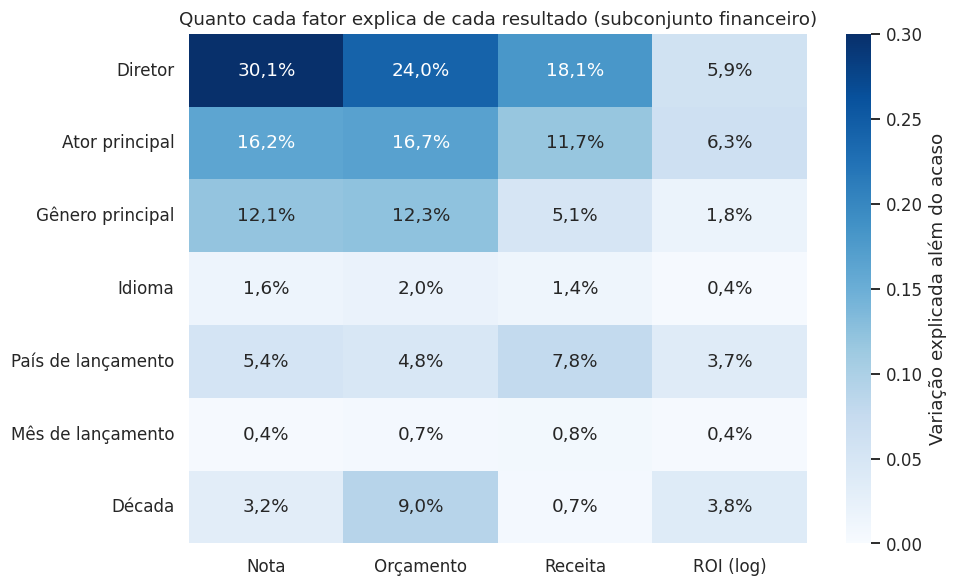

In [90]:
fin["log_orcamento"] = np.log10(fin["orcamento"])
fin["log_receita"] = np.log10(fin["receita"])
fin["log_roi"] = np.log10(fin["roi"])
fin["diretor_unico"] = fin["diretores_lista"].apply(lambda l: l[0] if len(l) == 1 else np.nan)

def explicado_acima_do_acaso(base, col, alvo, min_filmes=5, n_perm=30, seed=42):
    b = base.dropna(subset=[col, alvo])
    cont = b[col].value_counts()
    b = b[b[col].isin(cont[cont >= min_filmes].index)][[col, alvo]].copy()
    b[col] = b[col].astype(str)
    def eta(d):
        m = d[alvo].mean(); g = d.groupby(col)[alvo]
        return (g.size() * (g.mean() - m) ** 2).sum() / ((d[alvo] - m) ** 2).sum()
    rng = np.random.default_rng(seed)
    acaso = np.mean([eta(b.assign(**{col: rng.permutation(b[col].to_numpy())})) for _ in range(n_perm)])
    return eta(b) - acaso

fatores_amplo = {"Diretor": "diretor_unico", "Ator principal": "ator_principal", "Gênero principal": "genero_principal",
                 "Idioma": "idioma", "País de lançamento": "pais", "Mês de lançamento": "mes", "Década": "decada"}
alvos = {"Nota": "nota", "Orçamento": "log_orcamento", "Receita": "log_receita", "ROI (log)": "log_roi"}
matriz = pd.DataFrame({nome: {a: explicado_acima_do_acaso(fin, col, alvo) for a, alvo in alvos.items()}
                       for nome, col in fatores_amplo.items()}).T.clip(lower=0)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.heatmap(matriz, annot=matriz.map(lambda v: pct(v)), fmt="", cmap="Blues", vmin=0, vmax=0.3, ax=ax,
            cbar_kws={"label": "Variação explicada além do acaso"})
ax.set_title("Quanto cada fator explica de cada resultado (subconjunto financeiro)")
plt.tight_layout(); plt.show()

**Leitura (teste ampliado)**:

- **Gênero** pesa no orçamento (15%) e na nota (12%), mas pouco na receita (6%) e quase nada no ROI (2%). O gênero define quanto custa fazer o filme, não quanto ele rende por dólar.
- **Idioma** quase não explica nada (cerca de 1% em tudo). Não porque idioma não importe, mas porque 94% do `fin` é em inglês. Os filmes em japonês do `fin` têm a maior nota mediana (71) e o maior ROI (3,4), mas são só 48: só chega a ter bilheteria registrada aqui o filme estrangeiro que já fez sucesso.
- **País de lançamento** explica 10% da receita, mas pelo motivo do cuidado acima: filmes com data da Austrália faturam, na mediana, US$ 92 milhões, contra US$ 28 milhões dos com data dos EUA. A coluna está medindo **alcance de distribuição**, não um efeito de local.
- **Mês de lançamento** explica cerca de 1% de cada resultado. A sazonalidade existe, mas é pequena (gráfico abaixo).
- **Década** explica 5% do ROI, mas é o viés de sobrevivência da P1 de novo: os filmes antigos que restaram são os grandes sucessos.

**E daí?** O ponto mais importante está na coluna do ROI. Quase nada explica o retorno por dólar investido. O único fator com peso real é o **diretor** (7%). Data, local, idioma e gênero ajudam a prever quanto o filme vai custar e faturar, mas não se ele vai render bem em relação ao que custou.

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/21_mes_de_lancamento_receita_mediana_e_proporcao_de_f.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/22_mes_de_lancamento_receita_mediana_e_proporcao_de_f.png


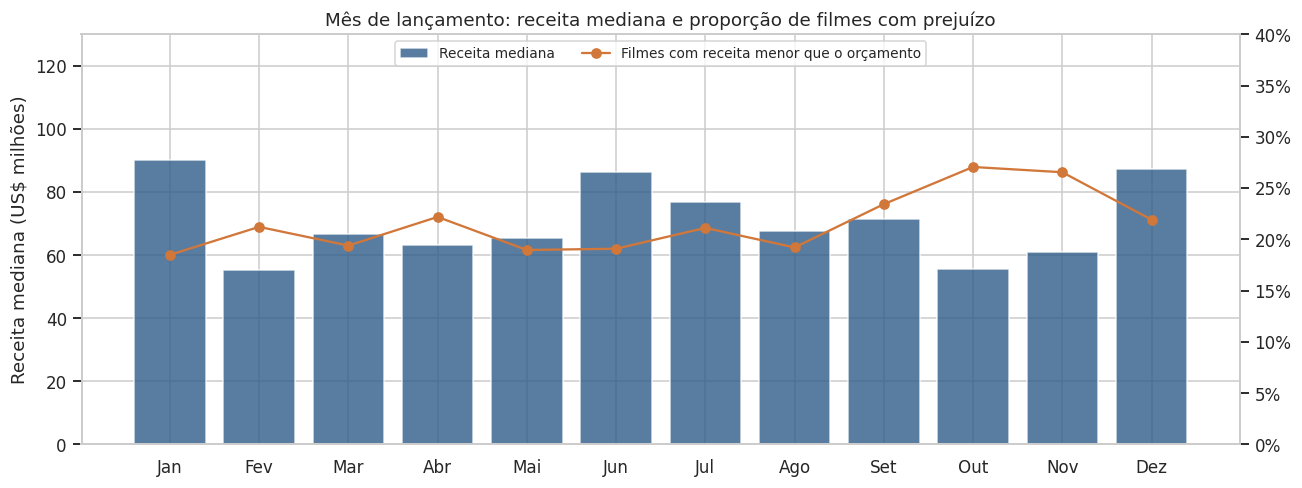

,filmes,receita_mediana,com_prejuizo,nota_mediana
mes,,,,
1,438,"90,092,828.50",0.18,66.00
2,377,"55,348,693.00",0.21,66.00
3,397,"66,787,173.00",0.19,65.00
4,338,"63,179,578.00",0.22,65.50
5,290,"65,461,534.50",0.19,65.00
6,351,"86,398,923.00",0.19,66.00
7,322,"76,803,762.50",0.21,65.00
8,406,"67,649,470.50",0.19,65.00
9,431,"71,600,000.00",0.23,65.00


In [91]:
por_mes = (fin.groupby("mes")
           .agg(filmes=("nota", "size"), receita_mediana=("receita", "median"),
                com_prejuizo=("roi", lambda s: (s < 1).mean()), nota_mediana=("nota", "median")))
nomes_meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar(nomes_meses, por_mes["receita_mediana"] / 1e6, color=AZUL, alpha=0.8, label="Receita mediana")
ax.set_ylabel("Receita mediana (US$ milhões)")
ax2 = ax.twinx()
ax2.plot(nomes_meses, por_mes["com_prejuizo"], color=LARANJA, marker="o", label="Filmes com receita menor que o orçamento")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0)); ax2.set_ylim(0, 0.4); ax2.grid(False)


ax.set_title("Mês de lançamento: receita mediana e proporção de filmes com prejuízo")
linhas = ax.get_legend_handles_labels(); linhas2 = ax2.get_legend_handles_labels()

ax.set_ylim(0, 130)
ax.legend(linhas[0] + linhas2[0], linhas[1] + linhas2[1], loc="upper center", ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

por_mes.round(2)

**Leitura (mês)**: junho, dezembro e janeiro têm as maiores receitas medianas (de US\$ 92 milhões a US\$ 99 milhões), as férias escolares no hemisfério norte e no sul. Outubro e novembro são os meses de maior risco: 28% e 31% dos filmes faturaram menos do que custaram, contra 18% a 22% em boa parte do ano. São também os meses com nota mediana um pouco maior (67 em novembro e dezembro), porque é quando estreiam os filmes que disputam prêmios: mais prestígio, menos bilheteria.

Ressalva: a data é, em geral, a de estreia na Austrália, que costuma ser próxima da dos EUA, mas não idêntica.

**E daí?** A data ajuda, mas pouco. Escolher o mês certo não salva um projeto, mas lançar um filme comercial na temporada de prêmios aumenta o risco.

---

---
### Síntese: o que move a nota e o que move a receita

Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/23_o_que_acompanha_a_nota_a_receita_e_o_retorno.png
Figura salva: /content/drive/MyDrive/TreinamentoNycollasRegilene/figuras/24_o_que_acompanha_a_nota_a_receita_e_o_retorno.png


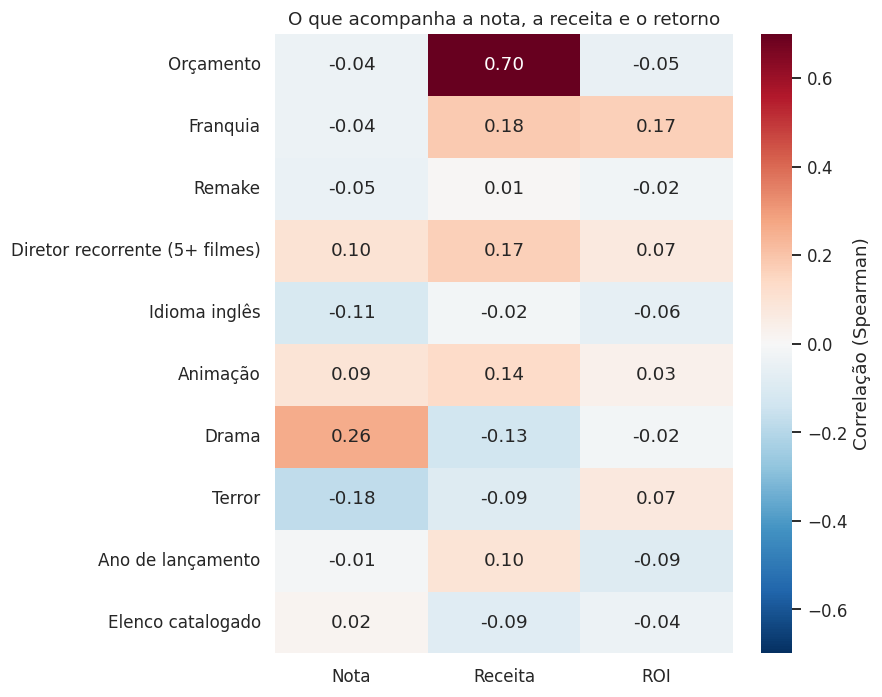

In [92]:
sintese = fin.assign(
    **{"Orçamento": fin["orcamento"],
       "Franquia": fin["e_franquia"].astype(int),
       "Remake": fin["E_remake?"],
       "Diretor recorrente (5+ filmes)": fin["diretores_lista"].apply(lambda l: int(any(n in ranking.index for n in l))),
       "Idioma inglês": (fin["idioma"] == "English").astype(int),
       "Animação": (fin["genero_principal"] == "Animation").astype(int),
       "Drama": (fin["genero_principal"] == "Drama").astype(int),
       "Terror": (fin["genero_principal"] == "Horror").astype(int),
       "Ano de lançamento": fin["ano"],
       "Elenco catalogado": fin["qtd_elenco"]})
fatores = ["Orçamento", "Franquia", "Remake", "Diretor recorrente (5+ filmes)", "Idioma inglês",
           "Animação", "Drama", "Terror", "Ano de lançamento", "Elenco catalogado"]
mapa = sintese[fatores + ["nota", "receita", "roi"]].corr(method="spearman").loc[fatores, ["nota", "receita", "roi"]]
mapa.columns = ["Nota", "Receita", "ROI"]

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(mapa, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-0.7, vmax=0.7, ax=ax, cbar_kws={"label": "Correlação (Spearman)"})
ax.set_title("O que acompanha a nota, a receita e o retorno")
plt.tight_layout(); plt.show()

**Leitura (síntese)**: o mapa resume a tensão do cliente numa imagem. Orçamento (0,67) e franquia (0,22) andam junto com **receita**, mas não com **nota**. Drama é o fator mais ligado à nota (0,27) e anda contra a receita (-0,13). Terror anda contra a nota (-0,15) e levemente a favor do retorno. Animação é o único gênero com sinal positivo nas três colunas ao mesmo tempo, ainda que fraco.

Os valores são baixos porque cada fator, sozinho, explica pouco: nenhum filme é só "drama" ou só "franquia". O mapa serve para ver a **direção** de cada fator, não para prever o resultado de um filme.

In [93]:
# Leitura das duas linhas que vêm do enriquecimento (Wikipedia e Wikidata)
def sinal(v):
    return "praticamente nenhuma relação" if abs(v) < 0.05 else ("relação positiva" if v > 0 else "relação negativa")
rem, dirr = mapa.loc["Remake"], mapa.loc["Diretor recorrente (5+ filmes)"]
display(Markdown(f"""- **Remake**: {sinal(rem['Nota'])} com a nota ({num(rem['Nota'], 2)}) e {sinal(rem['Receita'])} com a receita ({num(rem['Receita'], 2)}).
- **Diretor recorrente**: {sinal(dirr['Nota'])} com a nota ({num(dirr['Nota'], 2)}) e {sinal(dirr['Receita'])} com a receita ({num(dirr['Receita'], 2)}). Ter muitos filmes não é o mesmo que ser consistente: o que importa é o resíduo da P5, não o volume."""))

- **Remake**: praticamente nenhuma relação com a nota (-0,05) e praticamente nenhuma relação com a receita (0,01).
- **Diretor recorrente**: relação positiva com a nota (0,10) e relação positiva com a receita (0,17). Ter muitos filmes não é o mesmo que ser consistente: o que importa é o resíduo da P5, não o volume.

##6. Conclusões e recomendações ao cliente

In [94]:
# Os pontos que dependem do diretor (P4 e P5) são escritos a partir do resultado real
r = fatores_p4.set_index("fator")
d, a = r.loc["Diretor"], r.loc["Ator principal"]
contexto = r.drop(["Diretor", "Ator principal"])["acima_do_acaso"]
diretor_forte = d["acima_do_acaso"] > max(a["acima_do_acaso"], contexto.max()) and razao >= 1.5
diretor_medio = (not diretor_forte) and razao >= 1.5

if diretor_forte:
    ponto4 = (f"**4. Reputação vem de quem faz o filme.** Depois de trazer o diretor do Wikidata, ele passa a explicar "
              f"{pct(d['acima_do_acaso'])} da variação da nota além do acaso, mais do que o ator principal, o gênero, o idioma ou a década. "
              f"E {num(len(consistentes))} diretores superam o esperado de forma consistente, {num(razao, 1)} vezes mais do que o acaso produziria.")
    linha_reputacao = "| Reputação e retorno juntos | Diretores com histórico consistente e ROI acima da mediana | Ranking da P5 |"
elif diretor_medio:
    ponto4 = (f"**4. Quem faz o filme importa, mas não sozinho.** O diretor explica {pct(d['acima_do_acaso'])} da variação da nota além do acaso. "
              f"Não é o fator principal, mas existe um grupo de {num(len(consistentes))} diretores que supera o esperado de forma consistente, "
              f"{num(razao, 1)} vezes mais do que o acaso produziria.")
    linha_reputacao = "| Reputação e retorno juntos | Diretores consistentes do ranking da P5, combinados com gênero favorável | P4 e P5 |"
else:
    ponto4 = (f"**4. O diretor, sozinho, não explica a reputação.** Ele explica {pct(d['acima_do_acaso'])} da variação da nota além do acaso, "
              "e a consistência dos diretores fica perto do que o acaso produziria. Para encontrar um padrão de pessoas, "
              "é preciso trazer roteiro, produção e número de votos.")
    linha_reputacao = "| Reputação | Ainda sem nome a recomendar: falta roteiro, produção e votos | P4 e P5 |"

display(Markdown(f"""**O que o cliente perguntou:** o que faz um filme ser bem aceito, o que faz um filme dar retorno, e onde essas duas coisas não andam juntas.

**1. Reputação e dinheiro são objetivos diferentes.** A correlação entre nota e receita é fraca ({num(rho, 2)}). O cliente precisa definir, projeto a projeto, se está comprando bilheteria, reputação ou as duas, porque otimizar uma não entrega a outra.

**2. Dinheiro compra alcance e segurança, não qualidade.** Orçamento não tem relação com nota ({num(corr.loc['orcamento', 'nota'], 2)}), mas tem relação forte com receita ({num(corr.loc['orcamento', 'receita'], 2)}), e na faixa de maior orçamento só {pct(faixas['com_prejuizo'].iloc[-1], 0)} dos filmes faturaram menos do que custaram, contra {pct(faixas['com_prejuizo'].iloc[:-1].min(), 0)} a {pct(faixas['com_prejuizo'].iloc[:-1].max(), 0)} nas outras. Boa parte desse dinheiro vai para nomes conhecidos: com um protagonista experiente, orçamento e receita mais que dobram, mas nota e ROI ficam iguais. Data, local, idioma e gênero também ajudam a prever custo e faturamento, mas quase nada explica o retorno por dólar, a não ser o diretor.

**3. Franquia é a aposta financeira mais previsível, e a que mais consome reputação.** A receita de uma continuação fica próxima da do primeiro filme, enquanto a nota cai cerca de 4 pontos e não se recupera.

{ponto4}

**5. Os dados têm limites, e eles foram tratados.** Só {pct(len(fin) / len(df), 0)} da base tem dado financeiro confiável. Sem o número de votos, as notas extremas pertencem a filmes obscuros. Essas limitações foram documentadas e, sempre que possível, compensadas com fontes externas.

**Em quem apostar e por quê:**

| Objetivo | Aposta | Evidência |
|---|---|---|
| Retorno previsível | Continuações de franquias estabelecidas | Receita estável entre filmes da mesma série (P8) |
| Retorno alto com pouco capital | Terror de baixo orçamento | Maior ROI mediano entre os gêneros, com a menor nota (P7) |
| Equilíbrio entre nota, receita e retorno | Animação | Único gênero com sinal positivo nas três medidas (síntese) |
{linha_reputacao}

**Próximos passos:** trazer o número de votos (IMDb `title.ratings`), roteirista e produtor (Wikidata), e a série oficial de cada filme (Wikidata P179) para substituir a detecção de franquia pelo título."""))

**O que o cliente perguntou:** o que faz um filme ser bem aceito, o que faz um filme dar retorno, e onde essas duas coisas não andam juntas.

**1. Reputação e dinheiro são objetivos diferentes.** A correlação entre nota e receita é fraca (0,14). O cliente precisa definir, projeto a projeto, se está comprando bilheteria, reputação ou as duas, porque otimizar uma não entrega a outra.

**2. Dinheiro compra alcance e segurança, não qualidade.** Orçamento não tem relação com nota (-0,04), mas tem relação forte com receita (0,70), e na faixa de maior orçamento só 8% dos filmes faturaram menos do que custaram, contra 23% a 27% nas outras. Boa parte desse dinheiro vai para nomes conhecidos: com um protagonista experiente, orçamento e receita mais que dobram, mas nota e ROI ficam iguais. Data, local, idioma e gênero também ajudam a prever custo e faturamento, mas quase nada explica o retorno por dólar, a não ser o diretor.

**3. Franquia é a aposta financeira mais previsível, e a que mais consome reputação.** A receita de uma continuação fica próxima da do primeiro filme, enquanto a nota cai cerca de 4 pontos e não se recupera.

**4. Reputação vem de quem faz o filme.** Depois de trazer o diretor do Wikidata, ele passa a explicar 35,5% da variação da nota além do acaso, mais do que o ator principal, o gênero, o idioma ou a década. E 116 diretores superam o esperado de forma consistente, 2,4 vezes mais do que o acaso produziria.

**5. Os dados têm limites, e eles foram tratados.** Só 47% da base tem dado financeiro confiável. Sem o número de votos, as notas extremas pertencem a filmes obscuros. Essas limitações foram documentadas e, sempre que possível, compensadas com fontes externas.

**Em quem apostar e por quê:**

| Objetivo | Aposta | Evidência |
|---|---|---|
| Retorno previsível | Continuações de franquias estabelecidas | Receita estável entre filmes da mesma série (P8) |
| Retorno alto com pouco capital | Terror de baixo orçamento | Maior ROI mediano entre os gêneros, com a menor nota (P7) |
| Equilíbrio entre nota, receita e retorno | Animação | Único gênero com sinal positivo nas três medidas (síntese) |
| Reputação e retorno juntos | Diretores com histórico consistente e ROI acima da mediana | Ranking da P5 |

**Próximos passos:** trazer o número de votos (IMDb `title.ratings`), roteirista e produtor (Wikidata), e a série oficial de cada filme (Wikidata P179) para substituir a detecção de franquia pelo título.

## 7. Exportação para o dashboard

In [95]:
# Base completa com as colunas criadas na análise + ranking de diretores
# sep=";" e decimal="," para o Power BI em pt-BR ler os números corretamente
extras = ["quadrante", "top_nota", "faixa_orcamento", "faixa_experiencia", "experiencia_ator", "log_roi"]
analitico = df.merge(fin[["id"] + extras], on="id", how="left")
for c in ["generos_lista", "atores", "diretores_lista"]:
    analitico[c] = analitico[c].apply(lambda l: " | ".join(l) if isinstance(l, list) else l)

analitico.to_csv(f"{PASTA}/imdb_analitico.csv", sep=";", decimal=",", encoding="utf-8-sig", index=False)
ranking.reset_index().to_csv(f"{PASTA}/ranking_diretores.csv", sep=";", decimal=",", encoding="utf-8-sig", index=False)

print(f"imdb_analitico.csv: {len(analitico):,} linhas e {analitico.shape[1]} colunas")
print(f"ranking_diretores.csv: {len(ranking):,} diretores")

imdb_analitico.csv: 9,790 linhas e 41 colunas
ranking_diretores.csv: 384 diretores
